# CITS4404 Part 2 — Trading Bot Optimisation

This notebook contains the shared setup for the Part 2 trading bot experiment. The main comparison is between three population-based optimisation algorithms: Genetic Algorithm (GA), Particle Swarm Optimisation (PSO), and Differential Evolution (DE). We also include Simulated Annealing (SA) as a single-state adaptive baseline.

Each method optimises the same trading bot design using the same parameter bounds, random seeds, evaluation budget, and back-testing fitness function. This keeps the comparison fair and repeatable.

The final bot is trained on Bitcoin data before 2020 and tested on unseen data from 2020 onwards.

## README / Reproducibility

To run this notebook, keep the Bitcoin price file named `bitcoin_data.csv` in the same folder as the notebook. The dataset used is the Bitcoin Historical Dataset from Kaggle:

https://www.kaggle.com/datasets/prasoonkottarathil/btcinusd

The main libraries used are NumPy, pandas, matplotlib, time, and SciPy.

The notebook should be run from top to bottom to reproduce the results. We use the same fixed seed list, `list(range(1, 16))`, and the same budget of 3000 fitness evaluations for each optimisation run. GA, PSO, DE, and SA all use the same training/test split, parameter bounds, fitness function, starting cash, transaction fee, and warmup-based test evaluation.

We do not use external optimisation libraries. The optimisation algorithms are implemented directly in the notebook so the search process and evaluation setup are clear.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Shared experiment settings.
# Keeping these values fixed makes the algorithm comparison fair.
MAX_EVALS = 3000
SEEDS = list(range(1, 16))

# Back-testing settings from the project specification.
STARTING_CASH = 1000
TRANSACTION_FEE = 0.03

# 14-dimensional bot parameter bounds.
# The first 7 values control the high-frequency signal.
# The last 7 values control the low-frequency signal.
BOUNDS = [
    (0, 1), (0, 1), (0, 1),              # high SMA/LMA/EMA weights
    (2, 50), (2, 50), (2, 50),           # high SMA/LMA/EMA windows
    (0.01, 0.99),                        # high EMA alpha

    (0, 1), (0, 1), (0, 1),              # low SMA/LMA/EMA weights
    (20, 200), (20, 200), (20, 200),     # low SMA/LMA/EMA windows
    (0.01, 0.99)                         # low EMA alpha
]

## Shared Trading Bot, Backtester, and Fitness Function

This section develops the shared trading-bot implementation used by all optimisation methods in this notebook. It includes the moving-average filters, signal generation, backtesting rules, fitness function, and warmup-based test evaluation.

The final `fitness(params)` function created here is used by GA, PSO, DE, and SA so that all methods are evaluated on the same optimisation problem.

## Data Loading and Train/Test Split

This section loads the shared Bitcoin dataset and splits it into training and testing periods. The optimisation algorithms use only the pre-2020 training data, while the 2020 onwards data is preserved for final unseen testing.

In [ ]:
def load_bitcoin_data(file_path):
    """
    Load the shared Bitcoin dataset and prepare it for backtesting.

    Args:
        file_path (str): Path to the Bitcoin CSV file.

    Returns:
        pd.DataFrame: Cleaned Bitcoin data sorted by date.
    """
    data = pd.read_csv(file_path)

    # Standardise column names so the code works with common CSV formats.
    data.columns = [col.strip().lower() for col in data.columns]

    # Try to identify the date column from common names.
    possible_date_columns = ["date", "timestamp", "time", "datetime", "unix"]
    date_column = None

    for col in possible_date_columns:
        if col in data.columns:
            date_column = col
            break

    if date_column is None:
        raise ValueError("No date/timestamp column found in the dataset.")

    # Convert the date column into datetime format.
    # If the date is stored as Unix time, detect whether it is in seconds or milliseconds.
    if pd.api.types.is_numeric_dtype(data[date_column]):
        unit = "s" if data[date_column].max() < 1e12 else "ms"
        data[date_column] = pd.to_datetime(data[date_column], unit=unit, errors="coerce")
    else:
        data[date_column] = pd.to_datetime(data[date_column], errors="coerce")

    # Remove rows where the date could not be parsed.
    data = data.dropna(subset=[date_column])

    # Sort by date so the backtester runs in chronological order.
    data = data.sort_values(date_column).reset_index(drop=True)

    # Try to identify the close price column.
    possible_close_columns = ["close", "price", "closing price"]
    close_column = None

    for col in possible_close_columns:
        if col in data.columns:
            close_column = col
            break

    if close_column is None:
        raise ValueError("No close price column found in the dataset.")

    # Keep only the columns needed for the main backtesting process.
    data = data[[date_column, close_column]].copy()
    data = data.rename(columns={date_column: "date", close_column: "close"})

    # Remove invalid close prices.
    data["close"] = pd.to_numeric(data["close"], errors="coerce")
    data = data.dropna(subset=["close"])
    data = data[data["close"] > 0]

    return data


def split_train_test(data, split_date="2020-01-01"):
    """
    Split Bitcoin data into training and testing sets.

    Args:
        data (pd.DataFrame): Cleaned Bitcoin data with date and close columns.
        split_date (str): First date of the test period.

    Returns:
        tuple: Training DataFrame and testing DataFrame.
    """
    split_date = pd.to_datetime(split_date)

    train_data = data[data["date"] < split_date].copy()
    test_data = data[data["date"] >= split_date].copy()

    return train_data, test_data

### Load Shared Dataset

The shared Bitcoin daily dataset is loaded and split into training and testing sets. The training set contains data before 2020 and is used during optimisation. The test set contains data from 2020 onwards and is kept for final unseen evaluation.

In [ ]:
DATA_PATH = "bitcoin_data.csv"

bitcoin_data = load_bitcoin_data(DATA_PATH)
train_data, test_data = split_train_test(bitcoin_data, split_date="2020-01-01")

# Store prices as arrays for the later bot and backtester code.
train_prices = train_data["close"].to_numpy(dtype=float)
test_prices = test_data["close"].to_numpy(dtype=float)

print("Dataset loaded successfully.")
print(f"Dataset path used: {DATA_PATH}")
print()
print(f"Full dataset rows: {len(bitcoin_data)}")
print(f"Full date range: {bitcoin_data['date'].min().date()} to {bitcoin_data['date'].max().date()}")
print()
print(f"Training rows: {len(train_data)}")
print(f"Training range: {train_data['date'].min().date()} to {train_data['date'].max().date()}")
print()
print(f"Testing rows: {len(test_data)}")
print(f"Testing range: {test_data['date'].min().date()} to {test_data['date'].max().date()}")

Dataset loaded successfully.
Dataset path used: bitcoin_data.csv

Full dataset rows: 2651
Full date range: 2014-11-28 to 2022-03-01

Training rows: 1860
Training range: 2014-11-28 to 2019-12-31

Testing rows: 791
Testing range: 2020-01-01 to 2022-03-01


## Quick Data Check

This section plots the Bitcoin closing price and marks the train/test split. This helps check that the data is in chronological order and that the unseen test period is clearly separated from the training period.

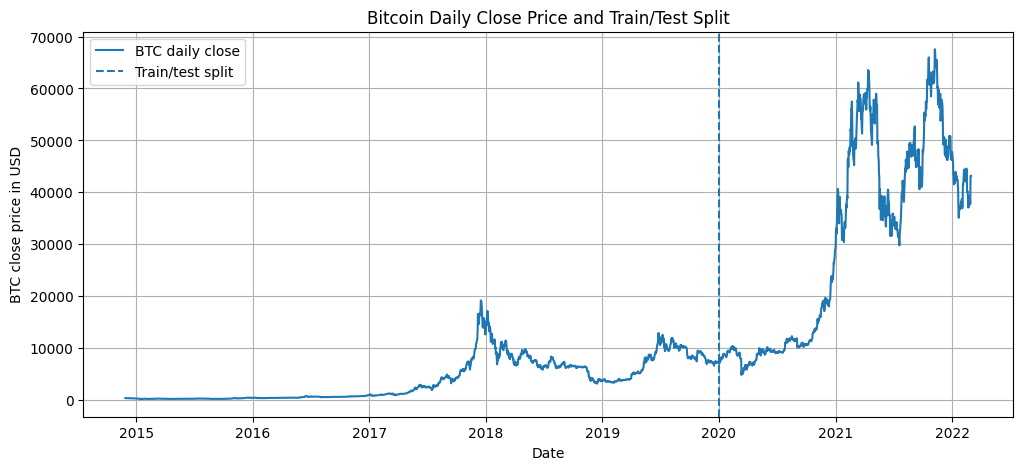

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(bitcoin_data["date"], bitcoin_data["close"], label="BTC daily close")
plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--", label="Train/test split")
plt.xlabel("Date")
plt.ylabel("BTC close price in USD")
plt.title("Bitcoin Daily Close Price and Train/Test Split")
plt.legend()
plt.grid(True)
plt.show()

The plot confirms that the Bitcoin data is in chronological order and that the train/test split occurs at 1 January 2020. The test period contains a much stronger upward price movement than most of the training period, which is useful context when interpreting why optimised strategies may not generalise as well as buy-and-hold.

## Moving Average Filters

This section implements the weighted moving-average filters used to construct the high-frequency and low-frequency trading signals.

The project specification shows flip-padding as one way to handle the start of a price series when the moving-average window is not yet full. In this implementation, we use `NaN` values for incomplete windows instead. This avoids applying flip-padding directly to raw Bitcoin prices, which can create artificial negative prices at the start of the dataset and produce unrealistic early moving-average values.

For the final test evaluation, the last 200 days of the training data are used as warmup data. This means the test-period indicators still have enough previous price history before trades are evaluated. The trade-off is that the first part of the training period cannot generate trades until the moving-average windows are complete.

### Implementation Choices for Moving Averages

The project specification defines the EMA filter as an exponentially decaying filter. In our implementation, we normalise the finite EMA filter so that its weights sum to one, like the SMA and LMA filters. We do this to keep the SMA, LMA, and EMA outputs on a comparable price scale before combining them in the weighted high-frequency and low-frequency signals. The smoothing factor `alpha` still controls the shape and rate of decay of the EMA weights.

The high-frequency window bounds are set to 2–50 days, while the low-frequency window bounds are set to 20–200 days. These bounds encourage the high-frequency signal to be more responsive than the low-frequency signal, but they do not strictly force every high-frequency window to be smaller than every low-frequency window. We kept this overlap so the optimiser still has flexibility, while the bounds still bias the search toward the intended crossover design.

Because we use `NaN` values for incomplete moving-average windows, crossover signals cannot be generated until enough price history is available. With the maximum low-frequency window of 200 days, up to 200 of the 1860 training days, or about 10.8%, cannot generate trades when the largest windows are used. For the test period, we use the final 200 days of training data as warmup, so the start of the unseen test period is still evaluated with enough indicator history.

In [ ]:
def sma_filter(window):
    """
    Create a Simple Moving Average filter.

    Args:
        window (int): Number of time steps in the moving-average window.

    Returns:
        np.ndarray: Normalised SMA filter weights.
    """
    return np.ones(window) / window


def lma_filter(window):
    """
    Create a Linear-Weighted Moving Average filter.

    Args:
        window (int): Number of time steps in the moving-average window.

    Returns:
        np.ndarray: Normalised LMA filter weights.
    """
    weights = np.arange(window, 0, -1, dtype=float)
    return weights / weights.sum()


def ema_filter(window, alpha):
    """
    Create an Exponential Moving Average filter.

    Args:
        window (int): Number of time steps in the moving-average window.
        alpha (float): EMA smoothing factor.

    Returns:
        np.ndarray: Normalised EMA filter weights.
    """
    weights = np.array([(1 - alpha) ** i for i in range(window)], dtype=float)
    return weights / weights.sum()


def apply_filter(prices, window, filter_weights):
    """
    Apply a moving-average filter to a price series.

    Args:
        prices (np.ndarray): Price series.
        window (int): Moving-average window size.
        filter_weights (np.ndarray): Filter weights to apply.

    Returns:
        np.ndarray: Filtered signal with NaN values where the window is incomplete.
    """
    if window < 1:
        raise ValueError("Window size must be at least 1.")

    if window > len(prices):
        return np.full(len(prices), np.nan)

    filtered_values = np.convolve(prices, filter_weights, mode="valid")

    signal = np.full(len(prices), np.nan)
    signal[window - 1:] = filtered_values

    return signal


def moving_average(prices, window, ma_type, alpha=0.5):
    """
    Calculate a moving-average signal using SMA, LMA, or EMA.

    Args:
        prices (np.ndarray): Price series.
        window (int): Moving-average window size.
        ma_type (str): Type of moving average: "SMA", "LMA", or "EMA".
        alpha (float): EMA smoothing factor, only used for EMA.

    Returns:
        np.ndarray: Moving-average signal.
    """
    window = int(round(window))

    if ma_type == "SMA":
        filter_weights = sma_filter(window)
    elif ma_type == "LMA":
        filter_weights = lma_filter(window)
    elif ma_type == "EMA":
        filter_weights = ema_filter(window, alpha)
    else:
        raise ValueError("ma_type must be 'SMA', 'LMA', or 'EMA'.")

    return apply_filter(prices, window, filter_weights)

## Trading Signal Construction

This section converts a 14-dimensional parameter vector into high-frequency and low-frequency signals. Each signal is a weighted combination of SMA, LMA, and EMA filters.

In [ ]:
def normalise_weights(weights):
    """
    Normalise a set of weights so that they sum to one.

    Args:
        weights (list or np.ndarray): Raw filter weights.

    Returns:
        np.ndarray: Normalised weights.
    """
    weights = np.array(weights, dtype=float)
    weights = np.clip(weights, 0, None)

    if weights.sum() == 0:
        return np.ones(len(weights)) / len(weights)

    return weights / weights.sum()


def build_weighted_signal(prices, weights, windows, alpha):
    """
    Build a weighted SMA/LMA/EMA signal from a price series.

    Args:
        prices (np.ndarray): Price series.
        weights (list or np.ndarray): Weights for SMA, LMA, and EMA.
        windows (list or np.ndarray): Window sizes for SMA, LMA, and EMA.
        alpha (float): EMA smoothing factor.

    Returns:
        np.ndarray: Weighted moving-average signal.
    """
    weights = normalise_weights(weights)

    sma_signal = moving_average(prices, windows[0], "SMA")
    lma_signal = moving_average(prices, windows[1], "LMA")
    ema_signal = moving_average(prices, windows[2], "EMA", alpha=alpha)

    weighted_signal = (
        weights[0] * sma_signal +
        weights[1] * lma_signal +
        weights[2] * ema_signal
    )

    return weighted_signal


def unpack_params(params):
    """
    Split the 14-dimensional parameter vector into high and low signal settings.

    Args:
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.

    Returns:
        dict: High-frequency and low-frequency signal parameters.
    """
    params = np.array(params, dtype=float)

    if len(params) != 14:
        raise ValueError("Parameter vector must contain exactly 14 values.")

    return {
        "high_weights": params[0:3],
        "high_windows": params[3:6],
        "high_alpha": params[6],
        "low_weights": params[7:10],
        "low_windows": params[10:13],
        "low_alpha": params[13]
    }


def generate_high_low_signals(prices, params):
    """
    Generate high-frequency and low-frequency trading signals.

    Args:
        prices (np.ndarray): Price series.
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.

    Returns:
        tuple: High-frequency signal and low-frequency signal.
    """
    settings = unpack_params(params)

    high_signal = build_weighted_signal(
        prices,
        settings["high_weights"],
        settings["high_windows"],
        settings["high_alpha"]
    )

    low_signal = build_weighted_signal(
        prices,
        settings["low_weights"],
        settings["low_windows"],
        settings["low_alpha"]
    )

    return high_signal, low_signal

## Buy and Sell Signal Generation

This section identifies crossover points between the high-frequency and low-frequency signals. A buy signal is generated when the high-frequency signal crosses above the low-frequency signal, and a sell signal is generated when it crosses below.

The project specification describes this idea using a sign-change filter in Equation (6). In this implementation, we use direct comparisons between the current and previous difference values to detect the same crossover events. This keeps the code simple while still following the same buy/sell signal logic.

In [ ]:
def generate_trade_signals(prices, params):
    """
    Generate buy and sell signals using high/low signal crossover points.

    Args:
        prices (np.ndarray): Price series.
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.

    Returns:
        np.ndarray: Signal array where 1 = buy, -1 = sell, and 0 = no action.
    """
    high_signal, low_signal = generate_high_low_signals(prices, params)

    difference = high_signal - low_signal
    signals = np.zeros(len(prices), dtype=int)

    for i in range(1, len(prices)):
        if np.isnan(difference[i - 1]) or np.isnan(difference[i]):
            continue

        # Buy when the high-frequency signal crosses above the low-frequency signal.
        if difference[i - 1] <= 0 and difference[i] > 0:
            signals[i] = 1

        # Sell when the high-frequency signal crosses below the low-frequency signal.
        elif difference[i - 1] >= 0 and difference[i] < 0:
            signals[i] = -1

    return signals

## Backtesting Function

This section simulates the trading bot on historical Bitcoin prices. The bot starts with $1000, trades using buy and sell signals, applies a 3% transaction fee, and returns the final cash value.

In [ ]:
def backtest_strategy(prices, params, starting_cash=STARTING_CASH, transaction_fee=TRANSACTION_FEE):
    """
    Backtest a trading bot parameter vector on a price series.

    Args:
        prices (np.ndarray): Price series used for the backtest.
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.
        starting_cash (float): Initial cash balance in USD.
        transaction_fee (float): Fee applied to each buy or sell transaction.

    Returns:
        dict: Backtest results including final cash, trades, and portfolio values.
    """
    signals = generate_trade_signals(prices, params)

    cash = starting_cash
    bitcoin = 0.0
    trades = []
    portfolio_values = []

    for i in range(len(prices)):
        price = prices[i]
        signal = signals[i]

        if signal == 1 and cash > 0:
            bitcoin = (cash * (1 - transaction_fee)) / price
            cash = 0.0

            trades.append({
                "index": i,
                "action": "BUY",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        elif signal == -1 and bitcoin > 0:
            cash = bitcoin * price * (1 - transaction_fee)
            bitcoin = 0.0

            trades.append({
                "index": i,
                "action": "SELL",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        portfolio_value = cash + bitcoin * price
        portfolio_values.append(portfolio_value)

    # Sell any remaining Bitcoin at the final price.
    if bitcoin > 0:
        final_price = prices[-1]
        cash = bitcoin * final_price * (1 - transaction_fee)
        bitcoin = 0.0

        trades.append({
            "index": len(prices) - 1,
            "action": "FINAL_SELL",
            "price": final_price,
            "cash": cash,
            "bitcoin": bitcoin
        })

    return {
        "final_cash": cash,
        "trades": trades,
        "portfolio_values": np.array(portfolio_values),
        "num_trades": len(trades)
    }

## Fitness Function

This section defines the optimisation objective. Each candidate parameter vector is evaluated by running the backtester on the training price data. The fitness value is the final cash after backtesting, so higher values are better.

In [ ]:
def fitness(params, prices=None):
    """
    Evaluate a candidate trading bot parameter vector.

    Args:
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.
        prices (np.ndarray): Price series used for evaluation. If None, training prices are used.

    Returns:
        float: Final cash after backtesting, where higher is better.
    """
    if prices is None:
        prices = train_prices

    result = backtest_strategy(prices, params)
    return result["final_cash"]


def evaluate_on_train_and_test(params):
    """
    Evaluate a candidate parameter vector on both training and testing data.

    Args:
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.

    Returns:
        dict: Training and testing backtest results.
    """
    train_result = backtest_strategy(train_prices, params)
    test_result = backtest_test_with_warmup(params, warmup_prices, test_prices)

    return {
        "train": train_result,
        "test": test_result
    }

## Sanity Check

This section runs one valid parameter vector through the signal generator, backtester, and fitness function to confirm that the full trading-bot pipeline works before implementing the Genetic Algorithm.

In [ ]:
# Use the midpoint of each parameter bound as a simple valid test vector.
test_params = np.array([(lower + upper) / 2 for lower, upper in BOUNDS])

test_signals = generate_trade_signals(train_prices, test_params)
test_backtest = backtest_strategy(train_prices, test_params)
test_fitness = fitness(test_params)

print("Sanity check complete.")
print(f"Parameter vector length: {len(test_params)}")
print(f"Buy signals: {np.sum(test_signals == 1)}")
print(f"Sell signals: {np.sum(test_signals == -1)}")
print(f"Number of trades: {test_backtest['num_trades']}")
print(f"Final training cash: ${test_fitness:,.2f}")

Sanity check complete.
Parameter vector length: 14
Buy signals: 7
Sell signals: 8
Number of trades: 14
Final training cash: $27,494.74


## Reproducibility Note

The backtest is deterministic when the price data and bot parameters are fixed. This means the only stochasticity comes from the optimisation methods themselves. We therefore use fixed random seeds so that the GA, PSO, DE, and SA results are reproducible.

## Algorithm 1: Genetic Algorithm

This section implements the Genetic Algorithm used to optimise the 14-dimensional trading-bot parameter vector. The GA uses the shared fitness function, parameter bounds, random seeds, evaluation budget, and warmup-based test evaluation so that its results can be fairly compared with PSO and DE.

### GA Method

The Genetic Algorithm maintains a population of candidate parameter vectors. Each candidate is evaluated using the shared fitness function, where higher final cash after backtesting is better.

The GA uses tournament selection to choose parents, uniform crossover to recombine parameter values, Gaussian mutation to explore nearby solutions, and elitism to carry the best candidates into the next generation. The same evaluation budget and fixed seeds are used so the GA results can be compared fairly with PSO and DE.

In [ ]:
def get_bound_arrays(bounds):
    """
    Convert parameter bounds into separate lower and upper arrays.

    Args:
        bounds (list): List of (lower, upper) tuples.

    Returns:
        tuple: Lower-bound array and upper-bound array.
    """
    lower_bounds = np.array([bound[0] for bound in bounds], dtype=float)
    upper_bounds = np.array([bound[1] for bound in bounds], dtype=float)

    return lower_bounds, upper_bounds


def initialise_population(population_size, bounds, rng):
    """
    Create an initial GA population within the parameter bounds.

    Args:
        population_size (int): Number of individuals in the population.
        bounds (list): List of parameter bounds.
        rng (np.random.Generator): Random number generator.

    Returns:
        np.ndarray: Initial population matrix.
    """
    lower_bounds, upper_bounds = get_bound_arrays(bounds)

    population = lower_bounds + rng.random((population_size, len(bounds))) * (upper_bounds - lower_bounds)

    return population


def clip_to_bounds(params, bounds):
    """
    Clip a parameter vector so that it stays inside the valid bounds.

    Args:
        params (np.ndarray): Candidate parameter vector.
        bounds (list): List of parameter bounds.

    Returns:
        np.ndarray: Clipped parameter vector.
    """
    lower_bounds, upper_bounds = get_bound_arrays(bounds)

    return np.clip(params, lower_bounds, upper_bounds)


def evaluate_population(population, fitness_fn):
    """
    Evaluate every individual in a population.

    Args:
        population (np.ndarray): Population of candidate parameter vectors.
        fitness_fn (function): Fitness function to maximise.

    Returns:
        np.ndarray: Fitness score for each individual.
    """
    fitness_values = np.array([fitness_fn(individual) for individual in population])

    return fitness_values

In [ ]:
def tournament_selection(population, fitness_values, tournament_size, rng):
    """
    Select one parent using tournament selection.

    Args:
        population (np.ndarray): Current population of candidate solutions.
        fitness_values (np.ndarray): Fitness score for each individual.
        tournament_size (int): Number of individuals sampled in the tournament.
        rng (np.random.Generator): Random number generator.

    Returns:
        np.ndarray: Selected parent parameter vector.
    """
    selected_indices = rng.choice(len(population), size=tournament_size, replace=False)
    best_index = selected_indices[np.argmax(fitness_values[selected_indices])]

    return population[best_index].copy()


def uniform_crossover(parent_a, parent_b, crossover_rate, rng):
    """
    Create two children from two parents using uniform crossover.

    Args:
        parent_a (np.ndarray): First parent.
        parent_b (np.ndarray): Second parent.
        crossover_rate (float): Probability of applying crossover.
        rng (np.random.Generator): Random number generator.

    Returns:
        tuple: Two child parameter vectors.
    """
    if rng.random() > crossover_rate:
        return parent_a.copy(), parent_b.copy()

    mask = rng.random(len(parent_a)) < 0.5

    child_a = parent_a.copy()
    child_b = parent_b.copy()

    child_a[mask] = parent_b[mask]
    child_b[mask] = parent_a[mask]

    return child_a, child_b


def mutate(child, bounds, mutation_rate, mutation_scale, rng):
    """
    Mutate a child parameter vector using Gaussian noise.

    Args:
        child (np.ndarray): Child parameter vector.
        bounds (list): List of parameter bounds.
        mutation_rate (float): Probability of mutating each parameter.
        mutation_scale (float): Mutation size as a fraction of each parameter range.
        rng (np.random.Generator): Random number generator.

    Returns:
        np.ndarray: Mutated child clipped to valid bounds.
    """
    lower_bounds, upper_bounds = get_bound_arrays(bounds)
    parameter_ranges = upper_bounds - lower_bounds

    mutation_mask = rng.random(len(child)) < mutation_rate
    noise = rng.normal(0, mutation_scale * parameter_ranges)

    mutated_child = child.copy()
    mutated_child[mutation_mask] += noise[mutation_mask]

    return clip_to_bounds(mutated_child, bounds)

In [ ]:
def run_ga(fitness_fn, bounds, max_evals, seed):
    """
    Run a Genetic Algorithm on the trading bot parameter space.

    Args:
        fitness_fn (function): Fitness function to maximise.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations allowed.
        seed (int): Random seed for repeatability.

    Returns:
        tuple: Best parameter vector and convergence history.
    """
    rng = np.random.default_rng(seed)

    population_size = 30
    crossover_rate = 0.8
    mutation_rate = 0.1
    mutation_scale = 0.1
    tournament_size = 3
    elite_count = 2

    population = initialise_population(population_size, bounds, rng)

    fitness_values = []
    history = []

    best_params = None
    best_fitness = -np.inf
    evaluations_used = 0

    # Evaluate the initial population.
    for individual in population:
        if evaluations_used >= max_evals:
            break

        score = fitness_fn(individual)
        fitness_values.append(score)
        evaluations_used += 1

        if score > best_fitness:
            best_fitness = score
            best_params = individual.copy()

        history.append(best_fitness)

    fitness_values = np.array(fitness_values)

    while evaluations_used < max_evals:
        new_population = []
        new_fitness_values = []

        # Carry elite individuals forward without re-evaluating them.
        elite_indices = np.argsort(fitness_values)[-elite_count:]

        for index in elite_indices:
            new_population.append(population[index].copy())
            new_fitness_values.append(fitness_values[index])

        # Create and evaluate new children until the population is full.
        while len(new_population) < population_size and evaluations_used < max_evals:
            parent_a = tournament_selection(population, fitness_values, tournament_size, rng)
            parent_b = tournament_selection(population, fitness_values, tournament_size, rng)

            child_a, child_b = uniform_crossover(parent_a, parent_b, crossover_rate, rng)

            child_a = mutate(child_a, bounds, mutation_rate, mutation_scale, rng)
            child_b = mutate(child_b, bounds, mutation_rate, mutation_scale, rng)

            for child in [child_a, child_b]:
                if len(new_population) >= population_size or evaluations_used >= max_evals:
                    break

                child_fitness = fitness_fn(child)

                new_population.append(child)
                new_fitness_values.append(child_fitness)

                evaluations_used += 1

                if child_fitness > best_fitness:
                    best_fitness = child_fitness
                    best_params = child.copy()

                history.append(best_fitness)

        population = np.array(new_population)
        fitness_values = np.array(new_fitness_values)

    return best_params, history

In [ ]:
def run_ga_experiments(fitness_fn, bounds, max_evals, seeds):
    """
    Run GA for all fixed seeds and collect the results.

    Args:
        fitness_fn (function): Fitness function used during optimisation.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations per run.
        seeds (list): Random seeds used for repeated runs.

    Returns:
        tuple: Results list and convergence histories.
    """
    results = []
    histories = []

    for seed in seeds:
        print(f"Running GA seed {seed}...")
        start_time = time.time()

        best_params, history = run_ga(
            fitness_fn=fitness_fn,
            bounds=bounds,
            max_evals=max_evals,
            seed=seed
        )

        runtime = time.time() - start_time

        train_result = backtest_strategy(train_prices, best_params)
        test_result = backtest_test_with_warmup(best_params, warmup_prices, test_prices)

        best_train_fitness = train_result["final_cash"]
        test_fitness = test_result["final_cash"]

        results.append({
            "Algorithm": "GA",
            "Seed": seed,
            "Best Train Fitness": round(best_train_fitness, 2),
            "Test Fitness": round(test_fitness, 2),
            "Number of Trades": test_result["num_trades"],
            "Runtime Seconds": round(runtime, 3),
            "Best Params": best_params.copy(),
            "Notes": "Test evaluated with warmup"
        })

        histories.append(history)

        print(
            f"Seed {seed} complete | "
            f"Train: ${best_train_fitness:,.2f} | "
            f"Test: ${test_fitness:,.2f} | "
            f"Runtime: {runtime:.2f}s"
        )

    return results, histories

## Test Evaluation with Warmup

This section evaluates a trained bot on the test period while using the end of the training period as indicator warmup. The portfolio still starts from $1000 at the beginning of the test period.

In [ ]:
def backtest_test_with_warmup(params, warmup_prices, test_prices):
    """
    Evaluate a parameter vector on test data using earlier prices for indicator warmup.

    Args:
        params (list or np.ndarray): Candidate 14-dimensional parameter vector.
        warmup_prices (np.ndarray): Prices before the test period used only for indicators.
        test_prices (np.ndarray): Test-period prices used for portfolio evaluation.

    Returns:
        dict: Backtest result for the test period.
    """
    combined_prices = np.concatenate([warmup_prices, test_prices])
    signals = generate_trade_signals(combined_prices, params)

    test_start = len(warmup_prices)

    cash = STARTING_CASH
    bitcoin = 0.0
    trades = []
    portfolio_values = []

    for i in range(test_start, len(combined_prices)):
        price = combined_prices[i]
        signal = signals[i]
        test_index = i - test_start

        if signal == 1 and cash > 0:
            bitcoin = (cash * (1 - TRANSACTION_FEE)) / price
            cash = 0.0

            trades.append({
                "index": test_index,
                "action": "BUY",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        elif signal == -1 and bitcoin > 0:
            cash = bitcoin * price * (1 - TRANSACTION_FEE)
            bitcoin = 0.0

            trades.append({
                "index": test_index,
                "action": "SELL",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        portfolio_values.append(cash + bitcoin * price)

    if bitcoin > 0:
        final_price = test_prices[-1]
        cash = bitcoin * final_price * (1 - TRANSACTION_FEE)
        bitcoin = 0.0

        trades.append({
            "index": len(test_prices) - 1,
            "action": "FINAL_SELL",
            "price": final_price,
            "cash": cash,
            "bitcoin": bitcoin
        })

    return {
        "final_cash": cash,
        "trades": trades,
        "portfolio_values": np.array(portfolio_values),
        "num_trades": len(trades)
    }


warmup_size = max([upper for lower, upper in BOUNDS if upper > 1])
warmup_size = int(warmup_size)

warmup_prices = train_prices[-warmup_size:]

print(f"Warmup size: {warmup_size} days")

Warmup size: 200 days


## GA Experiment Results

This section runs the Genetic Algorithm for the fixed set of random seeds and records the training fitness, testing fitness, runtime, number of trades, and best parameter vector for each run.

In [ ]:
ga_results, ga_histories = run_ga_experiments(
    fitness_fn=fitness,
    bounds=BOUNDS,
    max_evals=MAX_EVALS,
    seeds=SEEDS
)

ga_results_df = pd.DataFrame(ga_results)
ga_results_df

Running GA seed 1...
Seed 1 complete | Train: $54,769.99 | Test: $1,523.97 | Runtime: 25.19s
Running GA seed 2...
Seed 2 complete | Train: $65,147.68 | Test: $1,820.06 | Runtime: 23.07s
Running GA seed 3...
Seed 3 complete | Train: $60,284.78 | Test: $2,313.84 | Runtime: 24.33s
Running GA seed 4...
Seed 4 complete | Train: $60,270.18 | Test: $1,671.78 | Runtime: 24.73s
Running GA seed 5...
Seed 5 complete | Train: $59,432.35 | Test: $2,320.04 | Runtime: 24.33s
Running GA seed 6...
Seed 6 complete | Train: $59,426.47 | Test: $1,776.96 | Runtime: 25.33s
Running GA seed 7...
Seed 7 complete | Train: $65,301.57 | Test: $1,518.94 | Runtime: 22.99s
Running GA seed 8...
Seed 8 complete | Train: $61,616.20 | Test: $2,274.63 | Runtime: 24.54s
Running GA seed 9...
Seed 9 complete | Train: $60,726.79 | Test: $1,686.75 | Runtime: 24.31s
Running GA seed 10...
Seed 10 complete | Train: $65,102.65 | Test: $2,291.93 | Runtime: 24.38s
Running GA seed 11...
Seed 11 complete | Train: $54,937.72 | Test: $

,Algorithm,Seed,Best Train Fitness,Test Fitness,Number of Trades,Runtime Seconds,Best Params,Notes
0,GA,1,54769.99,1523.97,8,25.189,"[0.5380009123361262, 0.3204032300027227, 0.144...",Test evaluated with warmup
1,GA,2,65147.68,1820.06,6,23.070,"[0.11176498811910718, 0.19438296300537491, 0.0...",Test evaluated with warmup
2,GA,3,60284.78,2313.84,6,24.333,"[0.5057429486000933, 0.8571226777684446, 0.561...",Test evaluated with warmup
3,GA,4,60270.18,1671.78,6,24.731,"[0.3798571544949967, 0.580259147331739, 0.4275...",Test evaluated with warmup
4,GA,5,59432.35,2320.04,8,24.328,"[0.5126929673771622, 0.669682791882589, 0.5749...",Test evaluated with warmup
5,GA,6,59426.47,1776.96,6,25.334,"[0.0, 0.32008908146916, 0.0575701478321996, 17...",Test evaluated with warmup
6,GA,7,65301.57,1518.94,8,22.990,"[0.9031935634218344, 1.0, 0.9047546308830797, ...",Test evaluated with warmup
7,GA,8,61616.20,2274.63,6,24.538,"[0.30414477223958303, 0.6652089051886629, 0.87...",Test evaluated with warmup
8,GA,9,60726.79,1686.75,6,24.312,"[0.8217355029160738, 0.1772824452480048, 0.825...",Test evaluated with warmup
9,GA,10,65102.65,2291.93,6,24.375,"[0.5724271345021488, 0.07391733142742807, 0.79...",Test evaluated with warmup


## Baseline and Generalisation Check

This section compares the GA results against simple baseline strategies. This helps assess whether the optimised bot performs better than holding cash or buying and holding Bitcoin, and whether performance generalises from training data to unseen test data.

In [ ]:
def calculate_buy_and_hold(prices, starting_cash=STARTING_CASH, transaction_fee=TRANSACTION_FEE):
    """
    Calculate final cash for a buy-and-hold strategy.

    Args:
        prices (np.ndarray): Price series used for evaluation.
        starting_cash (float): Initial cash balance in USD.
        transaction_fee (float): Fee applied when buying and selling.

    Returns:
        float: Final cash after buying at the start and selling at the end.
    """
    bitcoin = (starting_cash * (1 - transaction_fee)) / prices[0]
    final_cash = bitcoin * prices[-1] * (1 - transaction_fee)

    return final_cash


train_buy_hold = calculate_buy_and_hold(train_prices)
test_buy_hold = calculate_buy_and_hold(test_prices)

best_train_index = ga_results_df["Best Train Fitness"].idxmax()
best_test_index = ga_results_df["Test Fitness"].idxmax()

best_train_run = ga_results_df.loc[best_train_index]
best_test_run = ga_results_df.loc[best_test_index]

print("Baseline and generalisation check")
print(f"No-trade baseline: ${STARTING_CASH:,.2f}")
print()
print(f"Train buy-and-hold: ${train_buy_hold:,.2f}")
print(f"Test buy-and-hold: ${test_buy_hold:,.2f}")
print()
print("Best GA run selected by training fitness")
print(f"Seed: {best_train_run['Seed']}")
print(f"Train fitness: ${best_train_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_train_run['Test Fitness']:,.2f}")
print(f"Generalisation gap: ${best_train_run['Best Train Fitness'] - best_train_run['Test Fitness']:,.2f}")
print()
print("Best GA test result across seeds")
print(f"Seed: {best_test_run['Seed']}")
print(f"Train fitness: ${best_test_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_test_run['Test Fitness']:,.2f}")
print()
print(f"GA summary across {len(SEEDS)} seeds")
print(f"Mean train fitness: ${ga_results_df['Best Train Fitness'].mean():,.2f}")
print(f"Mean test fitness: ${ga_results_df['Test Fitness'].mean():,.2f}")
print(f"Std train fitness: ${ga_results_df['Best Train Fitness'].std():,.2f}")
print(f"Std test fitness: ${ga_results_df['Test Fitness'].std():,.2f}")

Baseline and generalisation check
No-trade baseline: $1,000.00

Train buy-and-hold: $17,924.71
Test buy-and-hold: $5,660.26

Best GA run selected by training fitness
Seed: 7
Train fitness: $65,301.57
Test fitness: $1,518.94
Generalisation gap: $63,782.63

Best GA test result across seeds
Seed: 15
Train fitness: $60,702.09
Test fitness: $2,482.76

GA summary across 15 seeds
Mean train fitness: $61,353.77
Mean test fitness: $1,959.98
Std train fitness: $3,422.89
Std test fitness: $403.85


### GA Result Interpretation

The GA achieved strong performance on the training period, with a mean training fitness of USD 61,353.77 across the 15 seeds. This is much higher than the training buy-and-hold baseline of USD 17,924.71, showing that the GA was able to optimise the bot parameters for the pre-2020 data.

However, the test results were much lower than the training results. The mean test fitness was USD 1,959.98, which is above the no-trade baseline of USD 1,000.00 but below the test buy-and-hold baseline of USD 5,660.26. This suggests that the GA strategy improved over holding cash, but did not generalise as well as simply holding Bitcoin during the 2020 onwards test period.

The best GA run selected by training fitness was seed 7, with a training fitness of USD 65,301.57 and a test fitness of USD 1,518.94. The best GA test result came from seed 15, with a test fitness of USD 2,482.76. This difference between the best training run and the best test run shows why we avoid selecting the final bot using test-period performance.

## GA Convergence Plot

This section plots the best GA fitness over the number of fitness evaluations. This helps show how the Genetic Algorithm improves during optimisation.

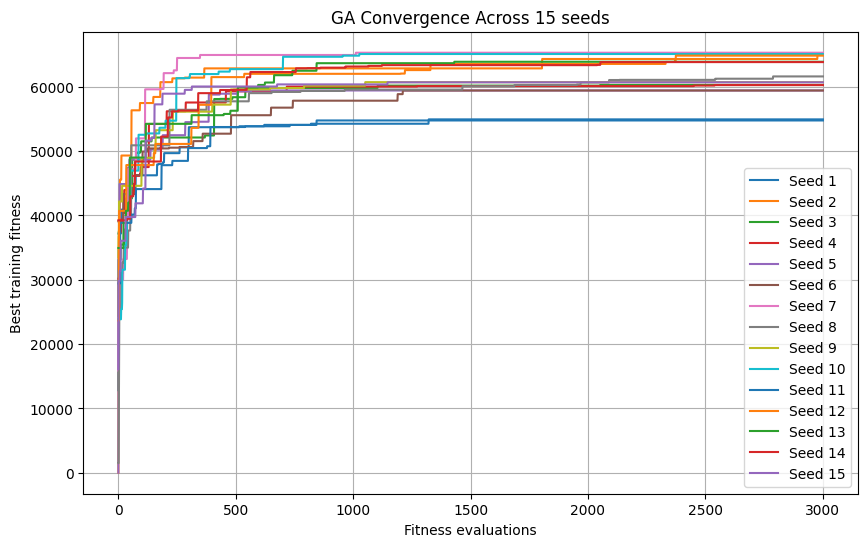

In [ ]:
def plot_ga_convergence(histories, seeds):
    """
    Plot GA convergence histories for all fixed seeds.

    Args:
        histories (list): Best-so-far fitness history for each GA run.
        seeds (list): Random seeds used for the GA runs.

    Returns:
        None
    """
    plt.figure(figsize=(10, 6))

    for history, seed in zip(histories, seeds):
        evaluations = np.arange(1, len(history) + 1)
        plt.plot(evaluations, history, label=f"Seed {seed}")

    plt.xlabel("Fitness evaluations")
    plt.ylabel("Best training fitness")
    plt.title(f"GA Convergence Across {len(SEEDS)} seeds")
    plt.legend()
    plt.grid(True)
    plt.savefig("ga_convergence.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_ga_convergence(ga_histories, SEEDS)

### GA Convergence Interpretation

The convergence plot shows that most GA runs improved quickly during the early fitness evaluations and then gradually levelled off. This indicates that the population usually found useful regions of the search space early, with smaller improvements occurring later in the run.

Seed 7 achieved the highest final training fitness, while several other seeds converged to slightly lower values. This variation shows that GA performance still depends on the initial random population and the evolutionary path. Running 15 fixed seeds gives a more reliable view of GA behaviour than using a single run.

## Algorithm 2: Particle Swarm Optimisation

This section implements Particle Swarm Optimisation to optimise the same 14-dimensional trading-bot parameter vector used by GA. PSO uses the same dataset, parameter bounds, random seeds, evaluation budget, fitness function, and warmup-based test evaluation, so the comparison remains fair.

### PSO Method

Particle Swarm Optimisation maintains a swarm of candidate solutions. Each particle has a position, velocity, personal best position, and the swarm also tracks the global best position.

The velocity update uses three components:

- inertia: keeps the particle moving in its current direction;
- cognitive component: pulls the particle toward its own best-known position;
- social component: pulls the particle toward the swarm's best-known position.

In this implementation, the inertia weight decreases linearly from 0.9 to 0.4. This encourages exploration early in the run and more stable convergence later.

In [ ]:
def run_pso(fitness_fn, bounds, max_evals, seed):
    """
    Run Particle Swarm Optimisation on the trading bot parameter space.

    Args:
        fitness_fn (function): Fitness function to maximise.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations allowed.
        seed (int): Random seed for repeatability.

    Returns:
        tuple: Best parameter vector and convergence history.
    """
    rng = np.random.default_rng(seed)

    num_particles = 30
    w_start = 0.9
    w_end = 0.4
    c1 = 1.5
    c2 = 1.5

    lower_bounds, upper_bounds = get_bound_arrays(bounds)
    parameter_ranges = upper_bounds - lower_bounds
    velocity_limit = 0.2 * parameter_ranges

    positions = lower_bounds + rng.random((num_particles, len(bounds))) * parameter_ranges
    velocities = (rng.random((num_particles, len(bounds))) * 2 - 1) * (0.1 * parameter_ranges)

    personal_best_positions = positions.copy()
    personal_best_fitness = np.full(num_particles, -np.inf)

    global_best_position = None
    global_best_fitness = -np.inf

    history = []
    evaluations_used = 0

    while evaluations_used < max_evals:
        progress = evaluations_used / max(max_evals - 1, 1)
        inertia_weight = w_start - progress * (w_start - w_end)

        for i in range(num_particles):
            if evaluations_used >= max_evals:
                break

            score = fitness_fn(positions[i])
            evaluations_used += 1

            if score > personal_best_fitness[i]:
                personal_best_fitness[i] = score
                personal_best_positions[i] = positions[i].copy()

            if score > global_best_fitness:
                global_best_fitness = score
                global_best_position = positions[i].copy()

            history.append(global_best_fitness)

        for i in range(num_particles):
            r1 = rng.random(len(bounds))
            r2 = rng.random(len(bounds))

            cognitive_component = c1 * r1 * (personal_best_positions[i] - positions[i])
            social_component = c2 * r2 * (global_best_position - positions[i])

            velocities[i] = (
                inertia_weight * velocities[i]
                + cognitive_component
                + social_component
            )

            velocities[i] = np.clip(velocities[i], -velocity_limit, velocity_limit)
            positions[i] = np.clip(positions[i] + velocities[i], lower_bounds, upper_bounds)

    return global_best_position, history

In [ ]:
def run_pso_experiments(fitness_fn, bounds, max_evals, seeds):
    """
    Run PSO for all fixed seeds and collect the results.

    Args:
        fitness_fn (function): Fitness function used during optimisation.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations per run.
        seeds (list): Random seeds used for repeated runs.

    Returns:
        tuple: Results list and convergence histories.
    """
    results = []
    histories = []

    for seed in seeds:
        print(f"Running PSO seed {seed}...")
        start_time = time.time()

        best_params, history = run_pso(
            fitness_fn=fitness_fn,
            bounds=bounds,
            max_evals=max_evals,
            seed=seed
        )

        runtime = time.time() - start_time

        train_result = backtest_strategy(train_prices, best_params)
        test_result = backtest_test_with_warmup(best_params, warmup_prices, test_prices)

        best_train_fitness = train_result["final_cash"]
        test_fitness = test_result["final_cash"]

        results.append({
            "Algorithm": "PSO",
            "Seed": seed,
            "Best Train Fitness": round(best_train_fitness, 2),
            "Test Fitness": round(test_fitness, 2),
            "Number of Trades": test_result["num_trades"],
            "Runtime Seconds": round(runtime, 3),
            "Best Params": best_params.copy(),
            "Notes": "Test evaluated with warmup"
        })

        histories.append(history)

        print(
            f"Seed {seed} complete | "
            f"Train: ${best_train_fitness:,.2f} | "
            f"Test: ${test_fitness:,.2f} | "
            f"Runtime: {runtime:.2f}s"
        )

    return results, histories

## PSO Experiment Results

This section runs Particle Swarm Optimisation for the fixed set of random seeds and records the training fitness, testing fitness, runtime, number of trades, and best parameter vector for each run.

In [ ]:
pso_results, pso_histories = run_pso_experiments(
    fitness_fn=fitness,
    bounds=BOUNDS,
    max_evals=MAX_EVALS,
    seeds=SEEDS
)

pso_results_df = pd.DataFrame(pso_results)
pso_results_df

Running PSO seed 1...
Seed 1 complete | Train: $57,598.78 | Test: $1,796.24 | Runtime: 23.75s
Running PSO seed 2...
Seed 2 complete | Train: $63,055.67 | Test: $1,456.73 | Runtime: 22.48s
Running PSO seed 3...
Seed 3 complete | Train: $61,821.39 | Test: $2,262.48 | Runtime: 23.08s
Running PSO seed 4...
Seed 4 complete | Train: $64,903.10 | Test: $2,241.06 | Runtime: 23.37s
Running PSO seed 5...
Seed 5 complete | Train: $63,784.36 | Test: $2,254.08 | Runtime: 24.13s
Running PSO seed 6...
Seed 6 complete | Train: $64,900.21 | Test: $2,152.66 | Runtime: 23.60s
Running PSO seed 7...
Seed 7 complete | Train: $58,186.15 | Test: $3,396.71 | Runtime: 23.07s
Running PSO seed 8...
Seed 8 complete | Train: $63,910.65 | Test: $2,405.81 | Runtime: 23.94s
Running PSO seed 9...
Seed 9 complete | Train: $57,882.51 | Test: $1,605.42 | Runtime: 23.37s
Running PSO seed 10...
Seed 10 complete | Train: $64,981.70 | Test: $2,241.06 | Runtime: 27.30s
Running PSO seed 11...
Seed 11 complete | Train: $61,987.6

,Algorithm,Seed,Best Train Fitness,Test Fitness,Number of Trades,Runtime Seconds,Best Params,Notes
0,PSO,1,57598.78,1796.24,6,23.745,"[0.5757231336288077, 0.7782354856895306, 0.836...",Test evaluated with warmup
1,PSO,2,63055.67,1456.73,8,22.476,"[0.2789645291335815, 0.0, 0.11707240909215955,...",Test evaluated with warmup
2,PSO,3,61821.39,2262.48,6,23.077,"[0.49018855412679174, 0.6156128319442449, 0.29...",Test evaluated with warmup
3,PSO,4,64903.10,2241.06,6,23.370,"[0.0015289622849092108, 0.5379784655849786, 0....",Test evaluated with warmup
4,PSO,5,63784.36,2254.08,6,24.135,"[0.8110564939426835, 0.5204821274141891, 0.652...",Test evaluated with warmup
5,PSO,6,64900.21,2152.66,8,23.595,"[0.8636402682405007, 0.46868219314418474, 0.40...",Test evaluated with warmup
6,PSO,7,58186.15,3396.71,8,23.071,"[0.687543683008215, 0.44486774313348104, 0.571...",Test evaluated with warmup
7,PSO,8,63910.65,2405.81,6,23.936,"[0.12586139997315302, 0.9599175020449087, 0.59...",Test evaluated with warmup
8,PSO,9,57882.51,1605.42,6,23.369,"[0.5376429254803565, 0.6410266842779748, 0.536...",Test evaluated with warmup
9,PSO,10,64981.70,2241.06,6,27.297,"[0.6527379284781354, 0.3132506271566448, 0.811...",Test evaluated with warmup


## PSO Baseline and Generalisation Check

This section compares the PSO results against the no-trade and buy-and-hold baselines. This helps assess whether PSO generalises from the training data to the unseen test period.

In [ ]:
best_train_index = pso_results_df["Best Train Fitness"].idxmax()
best_test_index = pso_results_df["Test Fitness"].idxmax()

best_train_run = pso_results_df.loc[best_train_index]
best_test_run = pso_results_df.loc[best_test_index]

print("PSO baseline and generalisation check")
print(f"No-trade baseline: ${STARTING_CASH:,.2f}")
print()
print(f"Train buy-and-hold: ${train_buy_hold:,.2f}")
print(f"Test buy-and-hold: ${test_buy_hold:,.2f}")
print()
print("Best PSO run selected by training fitness")
print(f"Seed: {best_train_run['Seed']}")
print(f"Train fitness: ${best_train_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_train_run['Test Fitness']:,.2f}")
print(f"Generalisation gap: ${best_train_run['Best Train Fitness'] - best_train_run['Test Fitness']:,.2f}")
print()
print("Best PSO test result across seeds")
print(f"Seed: {best_test_run['Seed']}")
print(f"Train fitness: ${best_test_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_test_run['Test Fitness']:,.2f}")
print()
print(f"PSO summary across {len(SEEDS)} seeds")
print(f"Mean train fitness: ${pso_results_df['Best Train Fitness'].mean():,.2f}")
print(f"Mean test fitness: ${pso_results_df['Test Fitness'].mean():,.2f}")
print(f"Std train fitness: ${pso_results_df['Best Train Fitness'].std():,.2f}")
print(f"Std test fitness: ${pso_results_df['Test Fitness'].std():,.2f}")

PSO baseline and generalisation check
No-trade baseline: $1,000.00

Train buy-and-hold: $17,924.71
Test buy-and-hold: $5,660.26

Best PSO run selected by training fitness
Seed: 14
Train fitness: $65,300.55
Test fitness: $1,940.90
Generalisation gap: $63,359.65

Best PSO test result across seeds
Seed: 7
Train fitness: $58,186.15
Test fitness: $3,396.71

PSO summary across 15 seeds
Mean train fitness: $62,545.66
Mean test fitness: $2,163.64
Std train fitness: $2,742.35
Std test fitness: $477.14


### PSO Result Interpretation

The PSO runs achieved strong performance on the pre-2020 training period, with a mean training fitness of USD 62,545.66 across the 15 seeds. This shows that PSO was able to optimise the bot parameters effectively on the training data.

The mean PSO test fitness was USD 2,163.64, which is above the no-trade baseline of USD 1,000.00 but below the test buy-and-hold baseline of USD 5,660.26. This suggests that PSO generated positive return after transaction fees, but still did not match the performance of simply holding Bitcoin during the 2020 onwards test period.

The best PSO run selected by training fitness was seed 14, with a training fitness of USD 65,300.55 and a test fitness of USD 1,940.90. The best PSO test result came from seed 7, with a test fitness of USD 3,396.71. As with GA, this shows that the run with the best training fitness was not the same as the run with the best test fitness.

## PSO Convergence Plot

This section plots the best PSO fitness over the number of fitness evaluations for each fixed seed.

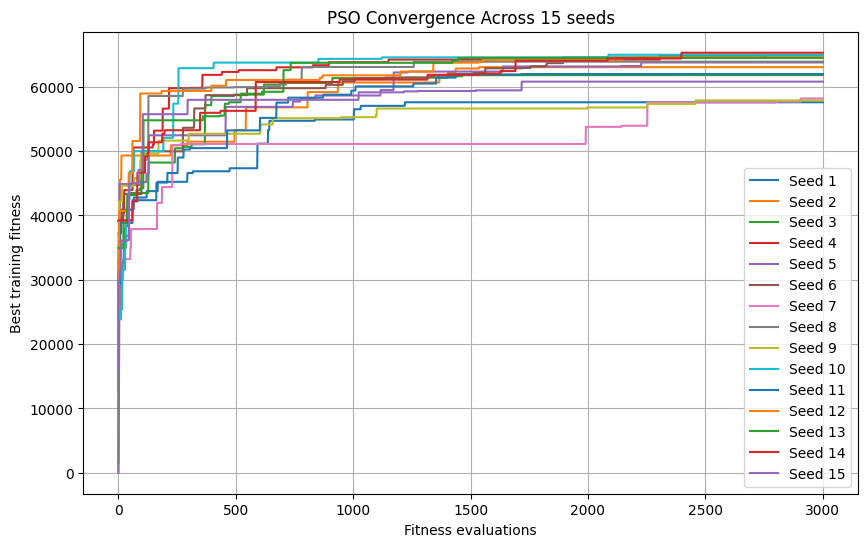

In [ ]:
def plot_pso_convergence(histories, seeds):
    """
    Plot PSO convergence histories for all fixed seeds.

    Args:
        histories (list): Best-so-far fitness history for each PSO run.
        seeds (list): Random seeds used for the PSO runs.

    Returns:
        None
    """
    plt.figure(figsize=(10, 6))

    for history, seed in zip(histories, seeds):
        evaluations = np.arange(1, len(history) + 1)
        plt.plot(evaluations, history, label=f"Seed {seed}")

    plt.xlabel("Fitness evaluations")
    plt.ylabel("Best training fitness")
    plt.title(f"PSO Convergence Across {len(SEEDS)} seeds")
    plt.legend()
    plt.grid(True)
    plt.savefig("pso_convergence.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_pso_convergence(pso_histories, SEEDS)

### PSO Convergence Interpretation

The PSO convergence plot shows that most runs improved rapidly during the early fitness evaluations, followed by smaller improvements later in the optimisation process. This suggests that the swarm usually identified useful regions of the parameter space early and then refined the best solutions more gradually.

Seed 14 achieved the highest final training fitness, while several other seeds finished close behind. The spread between the 15 seeds shows that PSO is still affected by initial particle positions and the swarm trajectory, so using multiple fixed seeds gives a more reliable view of its behaviour than a single run.

## Algorithm 3: Differential Evolution

This section implements Differential Evolution to optimise the same 14-dimensional trading-bot parameter vector used by GA and PSO. DE uses the same dataset, parameter bounds, random seeds, evaluation budget, fitness function, and warmup-based test evaluation, so the comparison remains fair.

### DE Method

Differential Evolution is a population-based optimisation algorithm for continuous parameter spaces. Each individual in the population represents one complete trading-bot parameter vector.

This implementation uses the DE/rand/1/bin strategy. For each target vector, three other population members are selected. A mutant vector is created by adding the scaled difference between two of them to the third. Binomial crossover then combines the target vector and mutant vector to create a trial vector.

If the trial vector gives an equal or better fitness value than the current target vector, it replaces the target in the population. The best fitness is tracked after each evaluation so that DE convergence can be compared with GA and PSO.

In [ ]:
DE_POPULATION_SIZE = 30
DE_MUTATION_FACTOR = 0.8
DE_CROSSOVER_RATE = 0.9


def initialise_de_population(population_size, bounds, rng):
    """
    Create an initial DE population within the parameter bounds.

    Args:
        population_size (int): Number of individuals in the population.
        bounds (list): List of parameter bounds.
        rng (np.random.Generator): Random number generator.

    Returns:
        np.ndarray: Initial DE population matrix.
    """
    lower_bounds = np.array([bound[0] for bound in bounds], dtype=float)
    upper_bounds = np.array([bound[1] for bound in bounds], dtype=float)

    return lower_bounds + rng.random((population_size, len(bounds))) * (upper_bounds - lower_bounds)


def run_de(fitness_fn, bounds, max_evals, seed):
    """
    Run Differential Evolution on the trading bot parameter space.

    Args:
        fitness_fn (function): Fitness function to maximise.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations allowed.
        seed (int): Random seed for repeatability.

    Returns:
        tuple: Best parameter vector and convergence history.
    """
    rng = np.random.default_rng(seed)

    population_size = DE_POPULATION_SIZE
    mutation_factor = DE_MUTATION_FACTOR
    crossover_rate = DE_CROSSOVER_RATE

    lower_bounds = np.array([bound[0] for bound in bounds], dtype=float)
    upper_bounds = np.array([bound[1] for bound in bounds], dtype=float)
    num_params = len(bounds)

    if population_size < 4:
        raise ValueError("DE/rand/1/bin requires at least four population members.")

    population = initialise_de_population(population_size, bounds, rng)
    fitness_values = np.array([fitness_fn(individual) for individual in population])

    evaluations_used = population_size

    best_index = np.argmax(fitness_values)
    best_params = population[best_index].copy()
    best_fitness = fitness_values[best_index]

    history = list(np.maximum.accumulate(fitness_values))

    while evaluations_used < max_evals:
        for target_index in range(population_size):
            if evaluations_used >= max_evals:
                break

            candidate_indices = [index for index in range(population_size) if index != target_index]
            r1, r2, r3 = rng.choice(candidate_indices, size=3, replace=False)

            mutant = population[r1] + mutation_factor * (population[r2] - population[r3])
            mutant = np.clip(mutant, lower_bounds, upper_bounds)

            crossover_mask = rng.random(num_params) < crossover_rate
            forced_index = rng.integers(0, num_params)
            crossover_mask[forced_index] = True

            trial = np.where(crossover_mask, mutant, population[target_index])
            trial = np.clip(trial, lower_bounds, upper_bounds)

            trial_fitness = fitness_fn(trial)
            evaluations_used += 1

            if trial_fitness >= fitness_values[target_index]:
                population[target_index] = trial
                fitness_values[target_index] = trial_fitness

                if trial_fitness >= best_fitness:
                    best_fitness = trial_fitness
                    best_params = trial.copy()

            history.append(best_fitness)

    return best_params, history

In [ ]:
def run_de_experiments(fitness_fn, bounds, max_evals, seeds):
    """
    Run DE for all fixed seeds and collect the results.

    Args:
        fitness_fn (function): Fitness function used during optimisation.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations per run.
        seeds (list): Random seeds used for repeated runs.

    Returns:
        tuple: Results list and convergence histories.
    """
    results = []
    histories = []

    for seed in seeds:
        print(f"Running DE seed {seed}...")
        start_time = time.time()

        best_params, history = run_de(
            fitness_fn=fitness_fn,
            bounds=bounds,
            max_evals=max_evals,
            seed=seed
        )

        runtime = time.time() - start_time

        train_result = backtest_strategy(train_prices, best_params)
        test_result = backtest_test_with_warmup(best_params, warmup_prices, test_prices)

        best_train_fitness = train_result["final_cash"]
        test_fitness = test_result["final_cash"]

        results.append({
            "Algorithm": "DE",
            "Seed": seed,
            "Best Train Fitness": round(best_train_fitness, 2),
            "Test Fitness": round(test_fitness, 2),
            "Number of Trades": test_result["num_trades"],
            "Runtime Seconds": round(runtime, 3),
            "Best Params": best_params.copy(),
            "Notes": "Test evaluated with warmup"
        })

        histories.append(history)

        print(
            f"Seed {seed} complete | "
            f"Train: ${best_train_fitness:,.2f} | "
            f"Test: ${test_fitness:,.2f} | "
            f"Runtime: {runtime:.2f}s"
        )

    return results, histories

## DE Experiment Results

This section runs Differential Evolution for the fixed set of random seeds and records the training fitness, testing fitness, runtime, number of trades, and best parameter vector for each run.

In [ ]:
de_results, de_histories = run_de_experiments(
    fitness_fn=fitness,
    bounds=BOUNDS,
    max_evals=MAX_EVALS,
    seeds=SEEDS
)

de_results_df = pd.DataFrame(de_results)
de_results_df

Running DE seed 1...
Seed 1 complete | Train: $59,038.62 | Test: $2,274.63 | Runtime: 23.06s
Running DE seed 2...
Seed 2 complete | Train: $61,974.50 | Test: $2,241.06 | Runtime: 23.85s
Running DE seed 3...
Seed 3 complete | Train: $57,676.94 | Test: $2,237.06 | Runtime: 23.70s
Running DE seed 4...
Seed 4 complete | Train: $55,093.23 | Test: $1,299.12 | Runtime: 22.89s
Running DE seed 5...
Seed 5 complete | Train: $59,833.75 | Test: $2,423.41 | Runtime: 22.79s
Running DE seed 6...
Seed 6 complete | Train: $61,472.75 | Test: $2,794.56 | Runtime: 23.48s
Running DE seed 7...
Seed 7 complete | Train: $55,273.74 | Test: $2,115.68 | Runtime: 23.62s
Running DE seed 8...
Seed 8 complete | Train: $58,860.26 | Test: $2,003.69 | Runtime: 24.24s
Running DE seed 9...
Seed 9 complete | Train: $58,242.65 | Test: $2,371.12 | Runtime: 22.11s
Running DE seed 10...
Seed 10 complete | Train: $58,039.24 | Test: $1,575.95 | Runtime: 23.60s
Running DE seed 11...
Seed 11 complete | Train: $60,887.25 | Test: $

,Algorithm,Seed,Best Train Fitness,Test Fitness,Number of Trades,Runtime Seconds,Best Params,Notes
0,DE,1,59038.62,2274.63,6,23.063,"[0.9456955103919048, 0.08208053229965848, 0.54...",Test evaluated with warmup
1,DE,2,61974.50,2241.06,6,23.852,"[0.9383008108436169, 0.3142882993447618, 1.0, ...",Test evaluated with warmup
2,DE,3,57676.94,2237.06,6,23.703,"[0.16971710001324286, 0.7185790066733513, 0.43...",Test evaluated with warmup
3,DE,4,55093.23,1299.12,8,22.888,"[1.0, 1.0, 0.7479117961296444, 50.0, 36.549675...",Test evaluated with warmup
4,DE,5,59833.75,2423.41,6,22.789,"[0.3921947044184705, 0.9279908862835635, 0.0, ...",Test evaluated with warmup
5,DE,6,61472.75,2794.56,6,23.479,"[1.0, 0.4890344217937924, 0.0, 37.710251552566...",Test evaluated with warmup
6,DE,7,55273.74,2115.68,8,23.622,"[0.14995307999838547, 0.6150398531725941, 0.35...",Test evaluated with warmup
7,DE,8,58860.26,2003.69,10,24.236,"[0.6400000000000001, 0.3451157057281719, 0.410...",Test evaluated with warmup
8,DE,9,58242.65,2371.12,6,22.114,"[0.2263712300784264, 1.0, 0.6693077508180004, ...",Test evaluated with warmup
9,DE,10,58039.24,1575.95,8,23.605,"[0.9393055537371003, 0.24273707761691704, 0.0,...",Test evaluated with warmup


## DE Baseline and Generalisation Check

This section compares the DE results against the no-trade and buy-and-hold baselines. This helps assess whether DE generalises from the training data to the unseen test period.

In [ ]:
best_train_index = de_results_df["Best Train Fitness"].idxmax()
best_test_index = de_results_df["Test Fitness"].idxmax()

best_train_run = de_results_df.loc[best_train_index]
best_test_run = de_results_df.loc[best_test_index]

print("DE baseline and generalisation check")
print(f"No-trade baseline: ${STARTING_CASH:,.2f}")
print()
print(f"Train buy-and-hold: ${train_buy_hold:,.2f}")
print(f"Test buy-and-hold: ${test_buy_hold:,.2f}")
print()
print("Best DE run selected by training fitness")
print(f"Seed: {best_train_run['Seed']}")
print(f"Train fitness: ${best_train_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_train_run['Test Fitness']:,.2f}")
print(f"Generalisation gap: ${best_train_run['Best Train Fitness'] - best_train_run['Test Fitness']:,.2f}")
print()
print("Best DE test result across seeds")
print(f"Seed: {best_test_run['Seed']}")
print(f"Train fitness: ${best_test_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_test_run['Test Fitness']:,.2f}")
print()
print(f"DE summary across {len(SEEDS)} seeds")
print(f"Mean train fitness: ${de_results_df['Best Train Fitness'].mean():,.2f}")
print(f"Mean test fitness: ${de_results_df['Test Fitness'].mean():,.2f}")
print(f"Std train fitness: ${de_results_df['Best Train Fitness'].std():,.2f}")
print(f"Std test fitness: ${de_results_df['Test Fitness'].std():,.2f}")

DE baseline and generalisation check
No-trade baseline: $1,000.00

Train buy-and-hold: $17,924.71
Test buy-and-hold: $5,660.26

Best DE run selected by training fitness
Seed: 2
Train fitness: $61,974.50
Test fitness: $2,241.06
Generalisation gap: $59,733.44

Best DE test result across seeds
Seed: 6
Train fitness: $61,472.75
Test fitness: $2,794.56

DE summary across 15 seeds
Mean train fitness: $58,680.67
Mean test fitness: $2,012.02
Std train fitness: $2,122.38
Std test fitness: $416.13


### DE Result Interpretation

The DE runs achieved strong performance on the pre-2020 training period, with a mean training fitness of USD 58,680.67 across the 15 seeds. This confirms that DE was able to optimise the trading-bot parameters under the same shared fitness function used by GA and PSO.

The mean DE test fitness was USD 2,012.02, which is above the no-trade baseline of USD 1,000.00 but below the test buy-and-hold baseline of USD 5,660.26. This shows that the DE-optimised bots generated positive return after transaction fees, but they still did not match the performance of simply holding Bitcoin during the 2020 onwards test period.

Compared with GA and PSO, DE no longer had the highest mean test fitness after increasing the experiment to 15 seeds. PSO had the highest mean test fitness among the three population-based methods, while DE remained in the same general performance range. The large gap between training and testing performance still suggests overfitting to the pre-2020 training data.

## DE Convergence Plot

This section plots the best DE fitness over the number of fitness evaluations for each fixed seed.

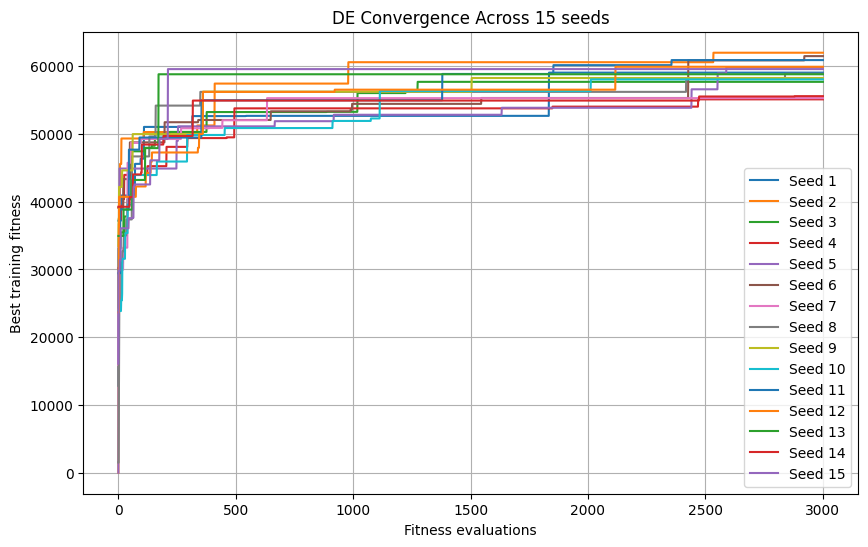

In [ ]:
def plot_de_convergence(histories, seeds):
    """
    Plot DE convergence histories for all fixed seeds.

    Args:
        histories (list): Best-so-far fitness history for each DE run.
        seeds (list): Random seeds used for the DE runs.

    Returns:
        None
    """
    plt.figure(figsize=(10, 6))

    for history, seed in zip(histories, seeds):
        evaluations = np.arange(1, len(history) + 1)
        plt.plot(evaluations, history, label=f"Seed {seed}")

    plt.xlabel("Fitness evaluations")
    plt.ylabel("Best training fitness")
    plt.title(f"DE Convergence Across {len(SEEDS)} seeds")
    plt.legend()
    plt.grid(True)
    plt.savefig("de_convergence.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_de_convergence(de_histories, SEEDS)

### DE Convergence Interpretation

The DE convergence plot shows that most improvement happened during the early fitness evaluations, followed by smaller stepwise improvements later in the run. This indicates that DE quickly found useful regions of the parameter space and then refined the best solutions more gradually.

Seed 2 achieved the highest final training fitness, while the other seeds finished slightly lower. The stepwise shape of the curves is expected because the plot records the best-so-far fitness, which only changes when a better parameter vector is found. Across 15 seeds, the final training fitness values stayed in a fairly similar range, suggesting that DE was reasonably consistent on the training objective.

## Single-State Baseline: Simulated Annealing

This section adds Simulated Annealing as a single-state adaptive baseline. Unlike GA, PSO, and DE, Simulated Annealing keeps only one current candidate solution at a time. It explores the search space by making random local changes to the current parameter vector.

If a new candidate improves the fitness, it is accepted. If it is worse, it may still be accepted with a probability controlled by the current temperature. The temperature gradually decreases during the run, so the algorithm explores more freely at the start and becomes more selective later.

We include Simulated Annealing to compare the population-based optimisers against an adaptive single-state search method under the same dataset, parameter bounds, random seeds, evaluation budget, fitness function, and warmup-based test evaluation.

In [ ]:
SA_INITIAL_TEMPERATURE = 1000.0
SA_MIN_TEMPERATURE = 0.1
SA_COOLING_RATE = 0.995
SA_STEP_SCALE = 0.1


def run_simulated_annealing(fitness_fn, bounds, max_evals, seed):
    """
    Run Simulated Annealing on the trading bot parameter space.

    Args:
        fitness_fn (function): Fitness function to maximise.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations allowed.
        seed (int): Random seed for repeatability.

    Returns:
        tuple: Best parameter vector and convergence history.
    """
    rng = np.random.default_rng(seed)

    lower_bounds, upper_bounds = get_bound_arrays(bounds)
    parameter_ranges = upper_bounds - lower_bounds

    current_params = lower_bounds + rng.random(len(bounds)) * parameter_ranges
    current_fitness = fitness_fn(current_params)

    best_params = current_params.copy()
    best_fitness = current_fitness

    temperature = SA_INITIAL_TEMPERATURE
    evaluations_used = 1
    history = [best_fitness]

    while evaluations_used < max_evals:
        candidate_params = current_params + rng.normal(
            0,
            SA_STEP_SCALE * parameter_ranges
        )
        candidate_params = np.clip(candidate_params, lower_bounds, upper_bounds)

        candidate_fitness = fitness_fn(candidate_params)
        evaluations_used += 1

        fitness_difference = candidate_fitness - current_fitness

        if fitness_difference > 0:
            accept_candidate = True
        else:
            acceptance_probability = np.exp(fitness_difference / temperature)
            accept_candidate = rng.random() < acceptance_probability

        if accept_candidate:
            current_params = candidate_params.copy()
            current_fitness = candidate_fitness

            if current_fitness > best_fitness:
                best_fitness = current_fitness
                best_params = current_params.copy()

        history.append(best_fitness)

        temperature = max(
            temperature * SA_COOLING_RATE,
            SA_MIN_TEMPERATURE
        )

    return best_params, history

In [ ]:
def run_sa_experiments(fitness_fn, bounds, max_evals, seeds):
    """
    Run SA for all fixed seeds and collect the results.

    Args:
        fitness_fn (function): Fitness function used during optimisation.
        bounds (list): List of parameter bounds.
        max_evals (int): Maximum number of fitness evaluations per run.
        seeds (list): Random seeds used for repeated runs.

    Returns:
        tuple: Results list and convergence histories.
    """
    results = []
    histories = []

    for seed in seeds:
        print(f"Running SA seed {seed}...")
        start_time = time.time()

        best_params, history = run_simulated_annealing(
            fitness_fn=fitness_fn,
            bounds=bounds,
            max_evals=max_evals,
            seed=seed
        )

        runtime = time.time() - start_time

        train_result = backtest_strategy(train_prices, best_params)
        test_result = backtest_test_with_warmup(best_params, warmup_prices, test_prices)

        best_train_fitness = train_result["final_cash"]
        test_fitness = test_result["final_cash"]

        results.append({
            "Algorithm": "SA",
            "Seed": seed,
            "Best Train Fitness": round(best_train_fitness, 2),
            "Test Fitness": round(test_fitness, 2),
            "Number of Trades": test_result["num_trades"],
            "Runtime Seconds": round(runtime, 3),
            "Best Params": best_params.copy(),
            "Notes": "Single-state baseline; test evaluated with warmup"
        })

        histories.append(history)

        print(
            f"Seed {seed} complete | "
            f"Train: ${best_train_fitness:,.2f} | "
            f"Test: ${test_fitness:,.2f} | "
            f"Runtime: {runtime:.2f}s"
        )

    return results, histories

## SA Experiment Results

This section runs Simulated Annealing for the fixed set of random seeds and records the training fitness, testing fitness, runtime, number of trades, and best parameter vector for each run.

In [ ]:
sa_results, sa_histories = run_sa_experiments(
    fitness_fn=fitness,
    bounds=BOUNDS,
    max_evals=MAX_EVALS,
    seeds=SEEDS
)

sa_results_df = pd.DataFrame(sa_results)
sa_results_df

Running SA seed 1...
Seed 1 complete | Train: $59,285.15 | Test: $1,679.19 | Runtime: 23.70s
Running SA seed 2...
Seed 2 complete | Train: $63,734.50 | Test: $2,241.06 | Runtime: 23.03s
Running SA seed 3...
Seed 3 complete | Train: $59,853.26 | Test: $1,522.61 | Runtime: 22.43s
Running SA seed 4...
Seed 4 complete | Train: $58,778.58 | Test: $2,464.94 | Runtime: 23.46s
Running SA seed 5...
Seed 5 complete | Train: $60,580.56 | Test: $1,448.40 | Runtime: 23.31s
Running SA seed 6...
Seed 6 complete | Train: $59,692.93 | Test: $1,934.57 | Runtime: 22.68s
Running SA seed 7...
Seed 7 complete | Train: $55,180.07 | Test: $2,005.87 | Runtime: 22.50s
Running SA seed 8...
Seed 8 complete | Train: $60,270.18 | Test: $1,662.09 | Runtime: 23.45s
Running SA seed 9...
Seed 9 complete | Train: $59,926.21 | Test: $1,396.99 | Runtime: 23.66s
Running SA seed 10...
Seed 10 complete | Train: $52,021.14 | Test: $4,394.14 | Runtime: 22.64s
Running SA seed 11...
Seed 11 complete | Train: $60,575.26 | Test: $

,Algorithm,Seed,Best Train Fitness,Test Fitness,Number of Trades,Runtime Seconds,Best Params,Notes
0,SA,1,59285.15,1679.19,6,23.701,"[0.7577395093675685, 1.0, 0.4959722181241254, ...",Single-state baseline; test evaluated with warmup
1,SA,2,63734.50,2241.06,6,23.029,"[0.1963310706978073, 0.9688338355711227, 0.956...",Single-state baseline; test evaluated with warmup
2,SA,3,59853.26,1522.61,6,22.434,"[0.7215421634405887, 0.04201678118777302, 1.0,...",Single-state baseline; test evaluated with warmup
3,SA,4,58778.58,2464.94,6,23.460,"[1.0, 0.21508414232718698, 0.9118310870845929,...",Single-state baseline; test evaluated with warmup
4,SA,5,60580.56,1448.40,8,23.311,"[0.44227822141736106, 0.39715123262076096, 0.0...",Single-state baseline; test evaluated with warmup
5,SA,6,59692.93,1934.57,6,22.684,"[0.8750497647205789, 0.021204949638824383, 0.6...",Single-state baseline; test evaluated with warmup
6,SA,7,55180.07,2005.87,6,22.502,"[0.37428046698941614, 1.0, 0.9120683640299061,...",Single-state baseline; test evaluated with warmup
7,SA,8,60270.18,1662.09,6,23.446,"[0.4203805084252577, 0.4344530853012501, 0.347...",Single-state baseline; test evaluated with warmup
8,SA,9,59926.21,1396.99,8,23.655,"[0.7660807419519216, 0.0, 0.7433895315328429, ...",Single-state baseline; test evaluated with warmup
9,SA,10,52021.14,4394.14,6,22.644,"[0.5326644096477339, 0.13635131161509934, 1.0,...",Single-state baseline; test evaluated with warmup


### SA Result Summary

The Simulated Annealing baseline produced training fitness values in a similar range to the population-based methods, showing that a single-state adaptive search can also find strong parameter vectors under the same evaluation budget.

However, the test results varied noticeably across seeds. Seed 10 achieved the best SA test fitness, with a test fitness of USD 4,394.14, while several other SA runs were much closer to the GA, PSO, and DE test ranges. This suggests that SA can occasionally find a strong test-performing solution, but its performance is still sensitive to the random initial solution and search path.

## SA Baseline and Generalisation Check

This section compares the Simulated Annealing baseline against the no-trade and buy-and-hold baselines. This helps assess whether the single-state adaptive baseline generalises from the training data to the unseen test period.

In [ ]:
best_train_index = sa_results_df["Best Train Fitness"].idxmax()
best_test_index = sa_results_df["Test Fitness"].idxmax()

best_train_run = sa_results_df.loc[best_train_index]
best_test_run = sa_results_df.loc[best_test_index]

print("SA baseline and generalisation check")
print(f"No-trade baseline: ${STARTING_CASH:,.2f}")
print()
print(f"Train buy-and-hold: ${train_buy_hold:,.2f}")
print(f"Test buy-and-hold: ${test_buy_hold:,.2f}")
print()
print("Best SA run selected by training fitness")
print(f"Seed: {best_train_run['Seed']}")
print(f"Train fitness: ${best_train_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_train_run['Test Fitness']:,.2f}")
print(f"Generalisation gap: ${best_train_run['Best Train Fitness'] - best_train_run['Test Fitness']:,.2f}")
print()
print("Best SA test result across seeds")
print(f"Seed: {best_test_run['Seed']}")
print(f"Train fitness: ${best_test_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_test_run['Test Fitness']:,.2f}")
print()
print(f"SA summary across {len(SEEDS)} seeds")
print(f"Mean train fitness: ${sa_results_df['Best Train Fitness'].mean():,.2f}")
print(f"Mean test fitness: ${sa_results_df['Test Fitness'].mean():,.2f}")
print(f"Std train fitness: ${sa_results_df['Best Train Fitness'].std():,.2f}")
print(f"Std test fitness: ${sa_results_df['Test Fitness'].std():,.2f}")

SA baseline and generalisation check
No-trade baseline: $1,000.00

Train buy-and-hold: $17,924.71
Test buy-and-hold: $5,660.26

Best SA run selected by training fitness
Seed: 2
Train fitness: $63,734.50
Test fitness: $2,241.06
Generalisation gap: $61,493.44

Best SA test result across seeds
Seed: 10
Train fitness: $52,021.14
Test fitness: $4,394.14

SA summary across 15 seeds
Mean train fitness: $59,128.45
Mean test fitness: $1,994.94
Std train fitness: $2,924.73
Std test fitness: $746.23


### SA Result Interpretation

The SA baseline achieved a mean training fitness of USD 59,128.45 across the 15 seeds, which is comparable to the population-based methods. This shows that a single-state adaptive search can still find strong training solutions for the trading-bot parameter space.

The mean SA test fitness was USD 1,994.94, which is above the no-trade baseline of USD 1,000.00 but below the test buy-and-hold baseline of USD 5,660.26. Seed 10 achieved the best SA test fitness at USD 4,394.14, which was the highest individual test result across all methods.

SA had a slightly lower mean test fitness than PSO, but it was close to GA and DE and also produced the best single test result. We test the method differences more formally in the Statistical Comparison section. Overall, SA remains a useful single-state baseline for this problem, even though it does not use the parallel exploration of a population.

## SA Convergence Plot

This section plots the best SA fitness over the number of fitness evaluations for each fixed seed.

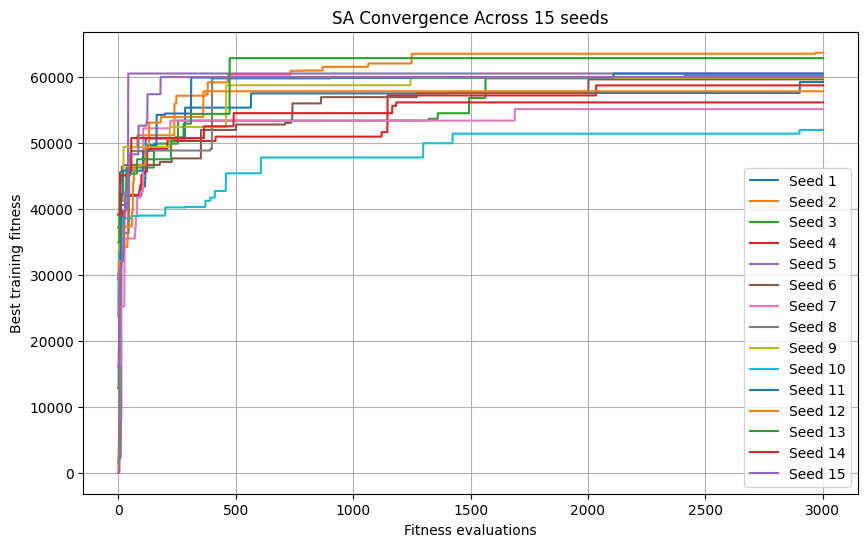

In [ ]:
def plot_sa_convergence(histories, seeds):
    """
    Plot SA convergence histories for all fixed seeds.

    Args:
        histories (list): Best-so-far fitness history for each SA run.
        seeds (list): Random seeds used for the SA runs.

    Returns:
        None
    """
    plt.figure(figsize=(10, 6))

    for history, seed in zip(histories, seeds):
        evaluations = np.arange(1, len(history) + 1)
        plt.plot(evaluations, history, label=f"Seed {seed}")

    plt.xlabel("Fitness evaluations")
    plt.ylabel("Best training fitness")
    plt.title(f"SA Convergence Across {len(SEEDS)} seeds")
    plt.legend()
    plt.grid(True)
    plt.savefig("sa_convergence.png", dpi=300, bbox_inches="tight")
    plt.show()


plot_sa_convergence(sa_histories, SEEDS)

### SA Convergence Interpretation

The SA convergence plot shows that most improvement occurred early in the search, followed by long plateau periods. This is expected because Simulated Annealing keeps only one current solution and records the best-so-far fitness, so the curve only changes when a better solution is found.

Compared with the population-based methods, SA has less parallel exploration because it does not maintain a population of candidate solutions. Even so, the 15-seed results show that SA was still able to find strong training solutions and one very strong test result. This makes it a useful single-state baseline rather than just a weaker optimiser.

## Bot Design Complexity Check: 2D SMA Crossover Baseline

The main bot in this notebook uses a 14-dimensional weighted SMA/LMA/EMA crossover design. To check whether the extra flexibility of that design was useful, we also test a much simpler 2-dimensional SMA crossover bot.

This simpler bot only optimises two parameters: the high-frequency SMA window and the low-frequency SMA window. We optimise it using DE with the same fixed seeds, same 3000-evaluation budget, same train/test split, same transaction fee, and the same warmup-based test evaluation. This gives us a direct comparison between a small search space and the richer 14-dimensional bot design.

In [ ]:
SMA_2D_BOUNDS = [
    (2, 50),      # high-frequency SMA window
    (20, 200)     # low-frequency SMA window
]


def generate_2d_sma_trade_signals(prices, params):
    """
    Generate buy/sell signals for a simple 2D SMA crossover bot.

    Args:
        prices (np.ndarray): Price series.
        params (list or np.ndarray): [high_window, low_window].

    Returns:
        np.ndarray: Signal array where 1 = buy, -1 = sell, and 0 = no action.
    """
    high_window = int(round(params[0]))
    low_window = int(round(params[1]))

    high_signal = moving_average(prices, high_window, "SMA")
    low_signal = moving_average(prices, low_window, "SMA")

    difference = high_signal - low_signal
    signals = np.zeros(len(prices), dtype=int)

    for i in range(1, len(prices)):
        if np.isnan(difference[i - 1]) or np.isnan(difference[i]):
            continue

        if difference[i - 1] <= 0 and difference[i] > 0:
            signals[i] = 1
        elif difference[i - 1] >= 0 and difference[i] < 0:
            signals[i] = -1

    return signals


def backtest_2d_sma_strategy(prices, params, starting_cash=STARTING_CASH, transaction_fee=TRANSACTION_FEE):
    """
    Backtest the 2D SMA crossover bot on a price series.
    """
    signals = generate_2d_sma_trade_signals(prices, params)

    cash = starting_cash
    bitcoin = 0.0
    trades = []
    portfolio_values = []

    for i in range(len(prices)):
        price = prices[i]
        signal = signals[i]

        if signal == 1 and cash > 0:
            bitcoin = (cash * (1 - transaction_fee)) / price
            cash = 0.0

            trades.append({
                "index": i,
                "action": "BUY",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        elif signal == -1 and bitcoin > 0:
            cash = bitcoin * price * (1 - transaction_fee)
            bitcoin = 0.0

            trades.append({
                "index": i,
                "action": "SELL",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        portfolio_values.append(cash + bitcoin * price)

    if bitcoin > 0:
        final_price = prices[-1]
        cash = bitcoin * final_price * (1 - transaction_fee)
        bitcoin = 0.0

        trades.append({
            "index": len(prices) - 1,
            "action": "FINAL_SELL",
            "price": final_price,
            "cash": cash,
            "bitcoin": bitcoin
        })

    return {
        "final_cash": cash,
        "trades": trades,
        "portfolio_values": np.array(portfolio_values),
        "num_trades": len(trades)
    }


def backtest_2d_sma_test_with_warmup(params, warmup_prices, test_prices):
    """
    Evaluate the 2D SMA crossover bot on test data using training warmup prices.
    """
    combined_prices = np.concatenate([warmup_prices, test_prices])
    signals = generate_2d_sma_trade_signals(combined_prices, params)

    test_start = len(warmup_prices)

    cash = STARTING_CASH
    bitcoin = 0.0
    trades = []
    portfolio_values = []

    for i in range(test_start, len(combined_prices)):
        price = combined_prices[i]
        signal = signals[i]
        test_index = i - test_start

        if signal == 1 and cash > 0:
            bitcoin = (cash * (1 - TRANSACTION_FEE)) / price
            cash = 0.0

            trades.append({
                "index": test_index,
                "action": "BUY",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        elif signal == -1 and bitcoin > 0:
            cash = bitcoin * price * (1 - TRANSACTION_FEE)
            bitcoin = 0.0

            trades.append({
                "index": test_index,
                "action": "SELL",
                "price": price,
                "cash": cash,
                "bitcoin": bitcoin
            })

        portfolio_values.append(cash + bitcoin * price)

    if bitcoin > 0:
        final_price = test_prices[-1]
        cash = bitcoin * final_price * (1 - TRANSACTION_FEE)
        bitcoin = 0.0

        trades.append({
            "index": len(test_prices) - 1,
            "action": "FINAL_SELL",
            "price": final_price,
            "cash": cash,
            "bitcoin": bitcoin
        })

    return {
        "final_cash": cash,
        "trades": trades,
        "portfolio_values": np.array(portfolio_values),
        "num_trades": len(trades)
    }


def fitness_2d_sma(params):
    """
    Fitness function for the 2D SMA crossover bot.
    """
    result = backtest_2d_sma_strategy(train_prices, params)
    return result["final_cash"]


def run_2d_sma_de_experiments(max_evals, seeds):
    """
    Optimise the 2D SMA crossover bot using DE for all fixed seeds.
    """
    results = []
    histories = []

    for seed in seeds:
        print(f"Running 2D SMA DE seed {seed}...")
        start_time = time.time()

        best_params, history = run_de(
            fitness_fn=fitness_2d_sma,
            bounds=SMA_2D_BOUNDS,
            max_evals=max_evals,
            seed=seed
        )

        runtime = time.time() - start_time

        train_result = backtest_2d_sma_strategy(train_prices, best_params)
        test_result = backtest_2d_sma_test_with_warmup(best_params, warmup_prices, test_prices)

        best_train_fitness = train_result["final_cash"]
        test_fitness = test_result["final_cash"]

        results.append({
            "Bot Design": "2D SMA crossover",
            "Algorithm": "DE",
            "Seed": seed,
            "Best Train Fitness": round(best_train_fitness, 2),
            "Test Fitness": round(test_fitness, 2),
            "Number of Trades": test_result["num_trades"],
            "Runtime Seconds": round(runtime, 3),
            "Best Params": best_params.copy(),
            "Notes": "2D design; test evaluated with warmup"
        })

        histories.append(history)

        print(
            f"Seed {seed} complete | "
            f"Train: ${best_train_fitness:,.2f} | "
            f"Test: ${test_fitness:,.2f} | "
            f"Runtime: {runtime:.2f}s"
        )

    return results, histories

In [ ]:
sma_2d_results, sma_2d_histories = run_2d_sma_de_experiments(
    max_evals=MAX_EVALS,
    seeds=SEEDS
)

sma_2d_results_df = pd.DataFrame(sma_2d_results)
sma_2d_results_df

Running 2D SMA DE seed 1...
Seed 1 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 22.46s
Running 2D SMA DE seed 2...
Seed 2 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 22.28s
Running 2D SMA DE seed 3...
Seed 3 complete | Train: $50,717.21 | Test: $1,622.70 | Runtime: 20.79s
Running 2D SMA DE seed 4...
Seed 4 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 22.31s
Running 2D SMA DE seed 5...
Seed 5 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 22.42s
Running 2D SMA DE seed 6...
Seed 6 complete | Train: $49,307.48 | Test: $2,129.36 | Runtime: 20.75s
Running 2D SMA DE seed 7...
Seed 7 complete | Train: $50,717.21 | Test: $1,622.70 | Runtime: 22.39s
Running 2D SMA DE seed 8...
Seed 8 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 21.93s
Running 2D SMA DE seed 9...
Seed 9 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 21.09s
Running 2D SMA DE seed 10...
Seed 10 complete | Train: $50,989.83 | Test: $1,814.44 | Runtime: 22.29

,Bot Design,Algorithm,Seed,Best Train Fitness,Test Fitness,Number of Trades,Runtime Seconds,Best Params,Notes
0,2D SMA crossover,DE,1,50989.83,1814.44,6,22.457,"[24.994468004532397, 146.13009668059306]",2D design; test evaluated with warmup
1,2D SMA crossover,DE,2,50989.83,1814.44,6,22.282,"[25.43359794676731, 146.1435396042973]",2D design; test evaluated with warmup
2,2D SMA crossover,DE,3,50717.21,1622.70,6,20.791,"[26.24536954297446, 152.84739437054074]",2D design; test evaluated with warmup
3,2D SMA crossover,DE,4,50989.83,1814.44,6,22.314,"[25.289302982250387, 146.0000166133139]",2D design; test evaluated with warmup
4,2D SMA crossover,DE,5,50989.83,1814.44,6,22.418,"[24.591905588639854, 145.57890705378995]",2D design; test evaluated with warmup
5,2D SMA crossover,DE,6,49307.48,2129.36,6,20.753,"[35.11078113994092, 166.92591564003368]",2D design; test evaluated with warmup
6,2D SMA crossover,DE,7,50717.21,1622.70,6,22.393,"[26.21879541092631, 153.1365118825533]",2D design; test evaluated with warmup
7,2D SMA crossover,DE,8,50989.83,1814.44,6,21.925,"[24.522895094426172, 145.88911783134247]",2D design; test evaluated with warmup
8,2D SMA crossover,DE,9,50989.83,1814.44,6,21.089,"[25.35281463988735, 145.81010524348625]",2D design; test evaluated with warmup
9,2D SMA crossover,DE,10,50989.83,1814.44,6,22.290,"[25.077032151619115, 145.8558771676156]",2D design; test evaluated with warmup


### 2D SMA Baseline Interpretation

The 2D SMA crossover baseline achieved a mean training fitness of USD 50,841.32 across the 15 seeds. This is lower than the 14-dimensional GA, PSO, DE, and SA results, which suggests that the richer weighted SMA/LMA/EMA bot design gave the optimisers more flexibility to fit the training period.

The mean 2D SMA test fitness was USD 1,809.87, which is above the no-trade baseline of USD 1,000.00 but still below the test buy-and-hold baseline of USD 5,660.26. The best 2D SMA test result was seed 6, with a test fitness of USD 2,129.36.

Most 2D SMA runs converged to very similar window values, with a high-frequency SMA window around 25 days and a low-frequency SMA window around 146 days. This suggests that the smaller 2D search space was more stable and easier to interpret, but it also had less flexibility than the 14-dimensional bot. Overall, the 2D baseline helps show the design trade-off: a simpler bot is more interpretable and stable, while the richer 14D bot can fit the training data better but also has more room to overfit.

### 2D versus 14D Design Comparison

To compare bot design complexity fairly, we compare the 2D SMA crossover bot against the 14-dimensional weighted SMA/LMA/EMA bot using DE for both designs. This keeps the optimiser the same and focuses the comparison on the effect of the parameterisation.

In [ ]:
design_complexity_comparison_df = pd.DataFrame([
    {
        "Bot Design": "2D SMA crossover",
        "Dimensions": 2,
        "Optimiser": "DE",
        "Mean Train Fitness": sma_2d_results_df["Best Train Fitness"].mean(),
        "Mean Test Fitness": sma_2d_results_df["Test Fitness"].mean(),
        "Best Test Fitness": sma_2d_results_df["Test Fitness"].max(),
        "Mean Runtime Seconds": sma_2d_results_df["Runtime Seconds"].mean(),
        "Mean Number of Trades": sma_2d_results_df["Number of Trades"].mean(),
        "Mean Generalisation Gap": (
            sma_2d_results_df["Best Train Fitness"].mean()
            - sma_2d_results_df["Test Fitness"].mean()
        )
    },
    {
        "Bot Design": "14D weighted SMA/LMA/EMA",
        "Dimensions": 14,
        "Optimiser": "DE",
        "Mean Train Fitness": de_results_df["Best Train Fitness"].mean(),
        "Mean Test Fitness": de_results_df["Test Fitness"].mean(),
        "Best Test Fitness": de_results_df["Test Fitness"].max(),
        "Mean Runtime Seconds": de_results_df["Runtime Seconds"].mean(),
        "Mean Number of Trades": de_results_df["Number of Trades"].mean(),
        "Mean Generalisation Gap": (
            de_results_df["Best Train Fitness"].mean()
            - de_results_df["Test Fitness"].mean()
        )
    }
])

numeric_columns = [
    "Mean Train Fitness",
    "Mean Test Fitness",
    "Best Test Fitness",
    "Mean Runtime Seconds",
    "Mean Number of Trades",
    "Mean Generalisation Gap"
]

design_complexity_comparison_df[numeric_columns] = design_complexity_comparison_df[numeric_columns].round(2)
design_complexity_comparison_df

,Bot Design,Dimensions,Optimiser,Mean Train Fitness,Mean Test Fitness,Best Test Fitness,Mean Runtime Seconds,Mean Number of Trades,Mean Generalisation Gap
0,2D SMA crossover,2,DE,50841.32,1809.87,2129.36,21.90,6.00,49031.45
1,14D weighted SMA/LMA/EMA,14,DE,58680.67,2012.02,2794.56,23.33,6.93,56668.65


### 2D versus 14D Design Comparison Interpretation

The 14D weighted SMA/LMA/EMA bot achieved a higher mean training fitness than the 2D SMA crossover bot, with USD 58,680.67 compared with USD 50,841.32. This suggests that the richer 14D parameterisation gave DE more flexibility to fit the training period.

On the unseen test period, the 14D bot also had a slightly higher mean test fitness, USD 2,012.02 compared with USD 1,809.87. However, the improvement was much smaller than the training improvement, and both designs remained below the test buy-and-hold baseline of USD 5,660.26.

The 14D bot also had a larger mean generalisation gap, USD 56,668.65 compared with USD 49,031.45 for the 2D bot. This supports the main design trade-off in this project: adding more parameters can improve training fit and give the optimiser more flexibility, but it also increases the search space and can make overfitting more likely. The simpler 2D bot was easier to interpret and produced very consistent window choices, while the 14D bot gave better average performance but with more complexity.

## Moving-Average Weight Aggregation Across Runs

The 14-dimensional bot uses separate SMA, LMA, and EMA weights for both the high-frequency and low-frequency signals. To see whether the optimisers consistently favoured one filter type, we aggregate the normalised moving-average weights across the best run from each seed for GA, PSO, DE, and SA.

In [ ]:
def extract_normalised_weight_summary(results_df):
    """
    Extract mean normalised high/low SMA, LMA, and EMA weights from a results DataFrame.

    Args:
        results_df (pd.DataFrame): Results table containing a Best Params column.

    Returns:
        dict: Mean normalised moving-average weights.
    """
    high_weights_list = []
    low_weights_list = []

    for params in results_df["Best Params"]:
        params = np.array(params, dtype=float)
        settings = unpack_params(params)

        high_weights_list.append(normalise_weights(settings["high_weights"]))
        low_weights_list.append(normalise_weights(settings["low_weights"]))

    high_weights_array = np.array(high_weights_list)
    low_weights_array = np.array(low_weights_list)

    return {
        "High SMA": high_weights_array[:, 0].mean(),
        "High LMA": high_weights_array[:, 1].mean(),
        "High EMA": high_weights_array[:, 2].mean(),
        "Low SMA": low_weights_array[:, 0].mean(),
        "Low LMA": low_weights_array[:, 1].mean(),
        "Low EMA": low_weights_array[:, 2].mean()
    }


weight_summary_rows = []

for method_name, method_df in [
    ("GA", ga_results_df),
    ("PSO", pso_results_df),
    ("DE", de_results_df),
    ("SA", sa_results_df)
]:
    row = {"Method": method_name}
    row.update(extract_normalised_weight_summary(method_df))
    weight_summary_rows.append(row)

weight_summary_df = pd.DataFrame(weight_summary_rows)
weight_summary_df = weight_summary_df.round(3)
weight_summary_df

,Method,High SMA,High LMA,High EMA,Low SMA,Low LMA,Low EMA
0,GA,0.345,0.328,0.327,0.394,0.415,0.191
1,PSO,0.340,0.309,0.351,0.452,0.353,0.195
2,DE,0.342,0.358,0.300,0.417,0.396,0.187
3,SA,0.353,0.282,0.365,0.370,0.390,0.239


### Moving-Average Weight Aggregation Interpretation

The moving-average weight summary shows that the optimisers did not completely collapse onto one filter type. For the high-frequency signal, the average SMA, LMA, and EMA weights were fairly balanced across the four methods. SA and PSO gave slightly more weight to EMA, while DE gave slightly more weight to LMA.

For the low-frequency signal, SMA and LMA generally received higher average weights than EMA. GA, PSO, and DE all gave the lowest low-frequency weight to EMA, while SA used EMA slightly more than the other methods. This suggests that the optimisers mostly used SMA and LMA for the smoother trend signal, while still keeping some EMA contribution.

Overall, the result supports keeping all three moving-average components in the 14D bot design. The optimiser did not consistently ignore any one component, but the lower EMA weight in the low-frequency signal suggests EMA was more useful for short-term responsiveness than for representing the broader trend.

## Combined Convergence Comparison

The individual convergence plots show how each optimiser behaved across seeds. To compare them more directly, this section plots the mean best-so-far training fitness for GA, PSO, DE, and SA on the same axis.

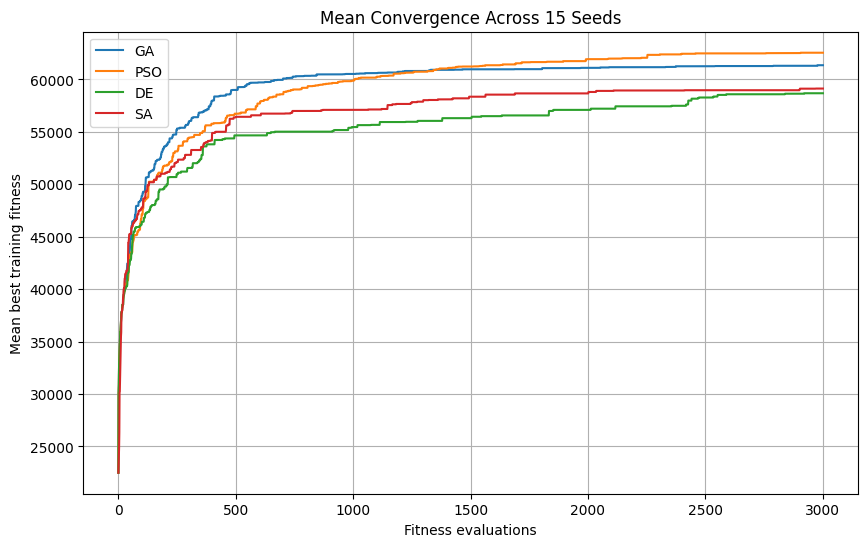

In [ ]:
def mean_convergence_history(histories):
    """
    Convert a list of convergence histories into a mean best-so-far curve.

    Args:
        histories (list): List of best-so-far fitness histories.

    Returns:
        tuple: Evaluation numbers and mean best-so-far fitness values.
    """
    min_length = min(len(history) for history in histories)
    trimmed_histories = np.array([history[:min_length] for history in histories])

    evaluations = np.arange(1, min_length + 1)
    mean_history = trimmed_histories.mean(axis=0)

    return evaluations, mean_history


plt.figure(figsize=(10, 6))

for method_name, histories in [
    ("GA", ga_histories),
    ("PSO", pso_histories),
    ("DE", de_histories),
    ("SA", sa_histories)
]:
    evaluations, mean_history = mean_convergence_history(histories)
    plt.plot(evaluations, mean_history, label=method_name)

plt.xlabel("Fitness evaluations")
plt.ylabel("Mean best training fitness")
plt.title(f"Mean Convergence Across {len(SEEDS)} Seeds")
plt.legend()
plt.grid(True)
plt.savefig("combined_convergence_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Combined Convergence Interpretation

The combined convergence plot shows that all four methods improved quickly during the early part of the search. GA had the fastest early improvement on average, but PSO continued to improve later and finished with the highest mean best training fitness across the 15 seeds.

DE and SA also improved quickly at the start, but their mean curves levelled off at lower training fitness values than GA and PSO. This does not mean they were ineffective, since all four methods still found strong training solutions compared with the buy-and-hold training baseline. However, it suggests that PSO and GA were slightly stronger on the training objective for this 14-dimensional bot design.

The plot also reinforces that higher training fitness did not automatically lead to better unseen test performance. The final comparison and statistical test are still needed to judge whether the observed differences between methods are meaningful on the test period.

## Parameter Similarity and Solution Diversity

The optimisers sometimes achieved similar training fitness values, but this does not necessarily mean they found the same bot parameters. To check this, we compare the best training-selected parameter vector from each method after normalising every parameter to the `[0, 1]` range using the shared bounds.

In [ ]:
def normalise_params_to_bounds(params, bounds):
    """
    Normalise a parameter vector to [0, 1] using the parameter bounds.

    Args:
        params (np.ndarray): Parameter vector.
        bounds (list): List of (lower, upper) bounds.

    Returns:
        np.ndarray: Normalised parameter vector.
    """
    params = np.array(params, dtype=float)
    lower_bounds, upper_bounds = get_bound_arrays(bounds)

    return (params - lower_bounds) / (upper_bounds - lower_bounds)


def get_method_best_params(results_df):
    """
    Get the parameter vector from the run with the best training fitness.

    Args:
        results_df (pd.DataFrame): Results table for one method.

    Returns:
        np.ndarray: Best training-selected parameter vector.
    """
    best_index = results_df["Best Train Fitness"].idxmax()
    return np.array(results_df.loc[best_index, "Best Params"], dtype=float)


method_best_params = {
    "GA": get_method_best_params(ga_results_df),
    "PSO": get_method_best_params(pso_results_df),
    "DE": get_method_best_params(de_results_df),
    "SA": get_method_best_params(sa_results_df)
}

normalised_method_params = {
    method: normalise_params_to_bounds(params, BOUNDS)
    for method, params in method_best_params.items()
}

method_names = list(normalised_method_params.keys())

distance_matrix = np.zeros((len(method_names), len(method_names)))

for i, method_i in enumerate(method_names):
    for j, method_j in enumerate(method_names):
        distance_matrix[i, j] = np.linalg.norm(
            normalised_method_params[method_i] - normalised_method_params[method_j]
        )

parameter_distance_df = pd.DataFrame(
    distance_matrix,
    index=method_names,
    columns=method_names
).round(3)

parameter_distance_df

,GA,PSO,DE,SA
GA,0.000,1.190,1.275,1.599
PSO,1.190,0.000,1.444,1.537
DE,1.275,1.444,0.000,1.764
SA,1.599,1.537,1.764,0.000


### Parameter Similarity Interpretation

The parameter distance table compares the best training-selected parameter vector from each method after normalising all 14 parameters to the same `[0, 1]` scale. The distances are not close to zero, which means the methods did not all converge to the exact same parameter vector.

GA and PSO had the smallest distance between their selected parameter vectors, while SA was furthest from DE. This suggests that different optimisation methods can find different regions of the parameter space while still achieving broadly similar training fitness values.

This is useful because it shows that the trading-bot search landscape likely has multiple good regions rather than one single obvious optimum. It also helps explain why similar training fitness did not always lead to similar test performance.

## Final Algorithm Comparison

This section compares the three population-based optimisation algorithms, GA, PSO, and DE, with the single-state SA baseline. All methods use the same dataset, parameter bounds, fixed seeds, evaluation budget, fitness function, and warmup-based test evaluation.

In [ ]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Mean train fitness",
        "Std train fitness",
        "Mean test fitness",
        "Std test fitness",
        "Best test fitness",
        "Mean runtime seconds",
        "Mean number of trades",
        "Mean test gain over no-trade baseline",
        "Mean test gap to buy-and-hold"
    ],
    "GA": [
        round(ga_results_df["Best Train Fitness"].mean(), 2),
        round(ga_results_df["Best Train Fitness"].std(), 2),
        round(ga_results_df["Test Fitness"].mean(), 2),
        round(ga_results_df["Test Fitness"].std(), 2),
        round(ga_results_df["Test Fitness"].max(), 2),
        round(ga_results_df["Runtime Seconds"].mean(), 2),
        round(ga_results_df["Number of Trades"].mean(), 2),
        round(ga_results_df["Test Fitness"].mean() - STARTING_CASH, 2),
        round(ga_results_df["Test Fitness"].mean() - test_buy_hold, 2)
    ],
    "PSO": [
        round(pso_results_df["Best Train Fitness"].mean(), 2),
        round(pso_results_df["Best Train Fitness"].std(), 2),
        round(pso_results_df["Test Fitness"].mean(), 2),
        round(pso_results_df["Test Fitness"].std(), 2),
        round(pso_results_df["Test Fitness"].max(), 2),
        round(pso_results_df["Runtime Seconds"].mean(), 2),
        round(pso_results_df["Number of Trades"].mean(), 2),
        round(pso_results_df["Test Fitness"].mean() - STARTING_CASH, 2),
        round(pso_results_df["Test Fitness"].mean() - test_buy_hold, 2)
    ],
    "DE": [
        round(de_results_df["Best Train Fitness"].mean(), 2),
        round(de_results_df["Best Train Fitness"].std(), 2),
        round(de_results_df["Test Fitness"].mean(), 2),
        round(de_results_df["Test Fitness"].std(), 2),
        round(de_results_df["Test Fitness"].max(), 2),
        round(de_results_df["Runtime Seconds"].mean(), 2),
        round(de_results_df["Number of Trades"].mean(), 2),
        round(de_results_df["Test Fitness"].mean() - STARTING_CASH, 2),
        round(de_results_df["Test Fitness"].mean() - test_buy_hold, 2)
    ],
    "SA": [
        round(sa_results_df["Best Train Fitness"].mean(), 2),
        round(sa_results_df["Best Train Fitness"].std(), 2),
        round(sa_results_df["Test Fitness"].mean(), 2),
        round(sa_results_df["Test Fitness"].std(), 2),
        round(sa_results_df["Test Fitness"].max(), 2),
        round(sa_results_df["Runtime Seconds"].mean(), 2),
        round(sa_results_df["Number of Trades"].mean(), 2),
        round(sa_results_df["Test Fitness"].mean() - STARTING_CASH, 2),
        round(sa_results_df["Test Fitness"].mean() - test_buy_hold, 2)
    ]
})

comparison_df

,Metric,GA,PSO,DE,SA
0,Mean train fitness,61353.77,62545.66,58680.67,59128.45
1,Std train fitness,3422.89,2742.35,2122.38,2924.73
2,Mean test fitness,1959.98,2163.64,2012.02,1994.94
3,Std test fitness,403.85,477.14,416.13,746.23
4,Best test fitness,2482.76,3396.71,2794.56,4394.14
5,Mean runtime seconds,24.18,23.43,23.33,23.06
6,Mean number of trades,6.80,6.40,6.93,6.40
7,Mean test gain over no-trade baseline,959.98,1163.64,1012.02,994.94
8,Mean test gap to buy-and-hold,-3700.29,-3496.62,-3648.24,-3665.32


### Final Comparison Interpretation

The final comparison shows that all four methods achieved strong training performance, with mean training fitness values well above the training buy-and-hold baseline. However, the test results were much lower than the training results for every method. This suggests that the bots were able to fit the pre-2020 training period well, but did not generalise as strongly to the unseen 2020 onwards test period.

Among the three population-based algorithms, PSO achieved the highest mean test fitness at USD 2,163.64, followed by DE at USD 2,012.02 and GA at USD 1,959.98. The single-state SA baseline had a mean test fitness of USD 1,994.94, which was close to GA and DE, and SA also produced the best individual test result at USD 4,394.14. This shows that the observed ranking depends on whether we look at mean test performance or the best single run.

All four methods performed above the no-trade baseline of USD 1,000.00, so each method found parameter settings that generated positive return after transaction fees. However, all four methods were still below the test buy-and-hold baseline of USD 5,660.26. This shows that the crossover-based bot design found some profitable trades, but did not capture the strong upward movement in the test period as effectively as simply holding Bitcoin.

Overall, PSO had the strongest mean test result among the four methods, while SA had the strongest individual test run. At this stage, we treat this as an observed pattern rather than proof that one optimiser is generally better, because the test results still need to be checked with the paired statistical comparison.

## Statistical Comparison of Test Fitness

This section compares the test fitness values across the 15 fixed seeds. These tests are used as a cautious supporting check rather than strong statistical proof, because the test fitness values still vary noticeably between runs.

In [ ]:
from scipy.stats import wilcoxon

test_fitness_by_method = {
    "GA": ga_results_df.sort_values("Seed")["Test Fitness"].to_numpy(),
    "PSO": pso_results_df.sort_values("Seed")["Test Fitness"].to_numpy(),
    "DE": de_results_df.sort_values("Seed")["Test Fitness"].to_numpy(),
    "SA": sa_results_df.sort_values("Seed")["Test Fitness"].to_numpy()
}

method_pairs = [
    ("GA", "PSO"),
    ("GA", "DE"),
    ("GA", "SA"),
    ("PSO", "DE"),
    ("PSO", "SA"),
    ("DE", "SA")
]

statistical_rows = []

for method_a, method_b in method_pairs:
    values_a = test_fitness_by_method[method_a]
    values_b = test_fitness_by_method[method_b]

    differences = values_b - values_a

    try:
        test_result = wilcoxon(values_b, values_a)
        statistic = test_result.statistic
        p_value = test_result.pvalue
    except ValueError:
        statistic = np.nan
        p_value = np.nan

    statistical_rows.append({
        "Comparison": f"{method_b} minus {method_a}",
        "Mean Difference": round(np.mean(differences), 2),
        "Median Difference": round(np.median(differences), 2),
        "Wilcoxon Statistic": statistic,
        "p-value": p_value
    })

statistical_comparison_df = pd.DataFrame(statistical_rows)
statistical_comparison_df

,Comparison,Mean Difference,Median Difference,Wilcoxon Statistic,p-value
0,PSO minus GA,203.66,34.62,40.0,0.276855
1,DE minus GA,52.05,-76.78,54.0,0.761536
2,SA minus GA,34.97,-162.78,55.0,0.803955
3,DE minus PSO,-151.62,-202.10,44.0,0.389404
4,SA minus PSO,-168.70,-218.09,43.0,0.359131
5,SA minus DE,-17.08,-109.81,40.0,0.432626


### Statistical Comparison Interpretation

The paired Wilcoxon tests do not show statistically significant differences between any pair of methods at the 0.05 level. This means the observed differences in test fitness should be treated cautiously rather than as strong evidence that one optimiser is generally better.

The mean differences still help describe the pattern in the results. PSO had a higher mean test fitness than GA, DE, and SA, while SA produced the best single test run. However, all p-values were well above 0.05, so these results are better interpreted as observed trends from this experiment rather than statistically significant differences.

Although 15 seeds gives a more reliable comparison than a single run, the test-period results still vary enough between seeds that the optimiser rankings are not statistically conclusive.

## Algorithm Characteristics and Hyperparameter Choices

This section summarises the main differences between the optimisation methods. GA, PSO, and DE are the main population-based methods, while SA is included as a single-state adaptive baseline.

| Method | Search type | Main mechanism | Key settings used | Why included |
|---|---|---|---|---|
| GA | Population-based evolutionary search | Selection, crossover, mutation, and elitism | Population size = 30, crossover rate = 0.8, mutation rate = 0.1, elite count = 2 | GA was used as the main evolutionary baseline, and it also links directly to the GA trading-rule paper reviewed in Part 1. |
| PSO | Population-based swarm search | Particles move using inertia, personal best, and global best | Particles = 30, inertia decreases from 0.9 to 0.4, `c1 = 1.5`, `c2 = 1.5` | PSO was used because it works naturally with continuous parameter vectors and is simpler than GA in terms of operators. |
| DE | Population-based evolutionary search | Differential mutation, crossover, and replacement | Population size = 30, mutation factor `F = 0.8`, crossover rate `CR = 0.9` | DE was used because it is simple to implement for real-valued optimisation and was designed for continuous search spaces. |
| SA | Single-state adaptive search | Random local moves accepted or rejected using a temperature schedule | Initial temperature = 1000, cooling rate = 0.995, step scale = 0.1 | SA was added as a single-state baseline so we could compare the population-based methods against a non-population method. |

We used the same evaluation budget and seed list for every method so that the comparison stayed fair. For GA, PSO, and DE, we used a population size of 30 to keep the population-based methods similar in scale. The remaining settings were chosen as standard starting values rather than being tuned separately for this dataset. This was intentional, because tuning each algorithm heavily would make the comparison less direct.

The purpose of this section is not to claim that these are the best possible hyperparameters. Instead, these settings provide a consistent and repeatable basis for comparing how the different search mechanisms behave on the same trading-bot optimisation problem.

The main hyperparameter values were chosen as standard, moderate starting settings rather than being tuned to maximise performance on this dataset. For GA, we used a population size of 30 with tournament selection, uniform crossover, mutation, and elitism, which is consistent with the common evolutionary algorithm components discussed by Katoch et al. (2021), reviewed in Part 1. For PSO, we used equal cognitive and social coefficients with an inertia weight decreasing from 0.9 to 0.4, following the inertia-weight idea proposed by Shi and Eberhart (1998), so particles explore more at the start and converge more later. For DE, we used the common `DE/rand/1/bin` setup with mutation factor `F = 0.8` and crossover rate `CR = 0.9`, which are standard settings associated with Storn and Price (1997) for continuous optimisation. For SA, the initial temperature, cooling rate, and step scale were chosen to allow some worse moves early in the run while gradually making the search more selective, consistent with the geometric cooling idea used in simulated annealing after Kirkpatrick et al. (1983). We kept these settings fixed across seeds so the comparison stayed focused on the optimisation methods rather than separate hyperparameter tuning.

## Transaction Fee and Buy-and-Hold Gap Discussion

A key reason the optimised bots did not beat buy-and-hold on the test period is the transaction fee. Each buy or sell action has a 3% fee. The buy-and-hold baseline only makes two transactions: one buy at the start and one final sell at the end. This creates roughly a 6% fee drag.

In comparison, the optimised crossover bots made around 6 to 7 trades on average during the test period. This means the trading strategies faced a much larger cumulative fee drag than buy-and-hold. For the bots to outperform buy-and-hold, they would need to avoid enough market downturns to compensate for these extra transaction costs.

The test period from 2020 onwards also had a strong upward price movement. In this type of market, buy-and-hold performs very well because it stays fully exposed to the upward trend. The crossover bots sometimes moved out of Bitcoin after sell signals, which helped reduce exposure during some downturns but also meant they missed parts of the overall rise. This helps explain why GA, PSO, DE, and SA all produced positive returns, but still finished below the buy-and-hold baseline.

## Training-Selected Final Bot

This section selects the final bot using training fitness only. This avoids using the unseen test period for model selection. After selecting the best training run across all methods, we report its test-period performance to assess generalisation.

In [ ]:
selection_results_df = pd.concat(
    [ga_results_df, pso_results_df, de_results_df, sa_results_df],
    ignore_index=True
)

best_training_index = selection_results_df["Best Train Fitness"].idxmax()
training_selected_bot = selection_results_df.loc[best_training_index]

print("Training-selected final bot")
print(f"Algorithm: {training_selected_bot['Algorithm']}")
print(f"Seed: {training_selected_bot['Seed']}")
print(f"Training fitness: ${training_selected_bot['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${training_selected_bot['Test Fitness']:,.2f}")
print(f"Number of test trades: {training_selected_bot['Number of Trades']}")
print()
print("This bot is selected using training fitness only. Its test fitness is reported only for final unseen evaluation.")

Training-selected final bot
Algorithm: GA
Seed: 7
Training fitness: $65,301.57
Test fitness: $1,518.94
Number of test trades: 8

This bot is selected using training fitness only. Its test fitness is reported only for final unseen evaluation.


## Training-Selected Bot Parameter Breakdown

This section decodes the training-selected bot's 14-dimensional parameter vector into the high-frequency and low-frequency signal settings. This helps show what type of moving-average combination was selected using training fitness only.

In [ ]:
PARAMETER_NAMES = [
    "High SMA weight", "High LMA weight", "High EMA weight",
    "High SMA window", "High LMA window", "High EMA window", "High EMA alpha",
    "Low SMA weight", "Low LMA weight", "Low EMA weight",
    "Low SMA window", "Low LMA window", "Low EMA window", "Low EMA alpha"
]


def decode_selected_params(params):
    """
    Decode a 14-dimensional parameter vector into readable bot settings.

    Args:
        params (np.ndarray): Candidate 14-dimensional parameter vector.

    Returns:
        pd.DataFrame: Table of raw and decoded parameter values.
    """
    settings = unpack_params(params)

    high_weights = normalise_weights(settings["high_weights"])
    low_weights = normalise_weights(settings["low_weights"])

    decoded_values = [
        high_weights[0], high_weights[1], high_weights[2],
        int(round(settings["high_windows"][0])),
        int(round(settings["high_windows"][1])),
        int(round(settings["high_windows"][2])),
        settings["high_alpha"],
        low_weights[0], low_weights[1], low_weights[2],
        int(round(settings["low_windows"][0])),
        int(round(settings["low_windows"][1])),
        int(round(settings["low_windows"][2])),
        settings["low_alpha"]
    ]

    return pd.DataFrame({
        "Parameter": PARAMETER_NAMES,
        "Raw Value": np.array(params, dtype=float),
        "Decoded Value": decoded_values
    })


training_selected_algorithm = training_selected_bot["Algorithm"]
training_selected_seed = training_selected_bot["Seed"]

if training_selected_algorithm == "GA":
    training_selected_params = ga_results_df.loc[
        ga_results_df["Seed"] == training_selected_seed, "Best Params"
    ].iloc[0]
elif training_selected_algorithm == "PSO":
    training_selected_params = pso_results_df.loc[
        pso_results_df["Seed"] == training_selected_seed, "Best Params"
    ].iloc[0]
elif training_selected_algorithm == "DE":
    training_selected_params = de_results_df.loc[
        de_results_df["Seed"] == training_selected_seed, "Best Params"
    ].iloc[0]
elif training_selected_algorithm == "SA":
    training_selected_params = sa_results_df.loc[
        sa_results_df["Seed"] == training_selected_seed, "Best Params"
    ].iloc[0]
else:
    raise ValueError(f"Unknown algorithm: {training_selected_algorithm}")

training_selected_params = np.array(training_selected_params, dtype=float)

training_selected_params_table = decode_selected_params(training_selected_params)
training_selected_params_table

,Parameter,Raw Value,Decoded Value
0,High SMA weight,0.903194,0.321656
1,High LMA weight,1.000000,0.356132
2,High EMA weight,0.904755,0.322212
3,High SMA window,37.435122,37.000000
4,High LMA window,41.446281,41.000000
5,High EMA window,2.000000,2.000000
6,High EMA alpha,0.633586,0.633586
7,Low SMA weight,0.822124,0.490969
8,Low LMA weight,0.420740,0.251264
9,Low EMA weight,0.431628,0.257766


### Training-Selected Bot Parameter Interpretation

The training-selected GA bot uses a fairly balanced high-frequency signal. The high-frequency weights for SMA, LMA, and EMA are all close, with LMA only slightly higher than SMA and EMA. This suggests that the selected bot did not rely on just one moving-average type for the faster signal.

For the low-frequency signal, the bot gives the largest weight to SMA, while LMA and EMA receive smaller but still meaningful weights. The low-frequency windows are much longer, with decoded values of 150, 134, and 120 days. This is consistent with the intended crossover design, where a more responsive high-frequency signal is compared against a smoother longer-term trend signal.

The high-frequency windows of 37, 41, and 2 days are clearly shorter than the low-frequency windows of 150, 134, and 120 days. This selected bot therefore follows the intended high-versus-low frequency structure more clearly than some earlier runs, while still using the flexible overlapping bounds defined in the Implementation Choices section.

### Moving-Average Weight Observation

The training-selected bot uses all three moving-average components rather than dropping one completely. In the high-frequency signal, SMA, LMA, and EMA have very similar normalised weights, so the faster signal is built from a balanced combination of filters.

In the low-frequency signal, SMA has the largest weight, while LMA and EMA still contribute to the smoother trend signal. This matches the broader weight aggregation result, where the optimisers generally kept all three components but tended to give SMA and LMA more importance in the low-frequency signal.

## Training-Selected Bot Test Trades

This section visualises the training-selected bot's buy and sell decisions on the unseen test period. The bot was selected using training fitness only, so this plot is used to inspect how that training-selected strategy behaved during final test evaluation.

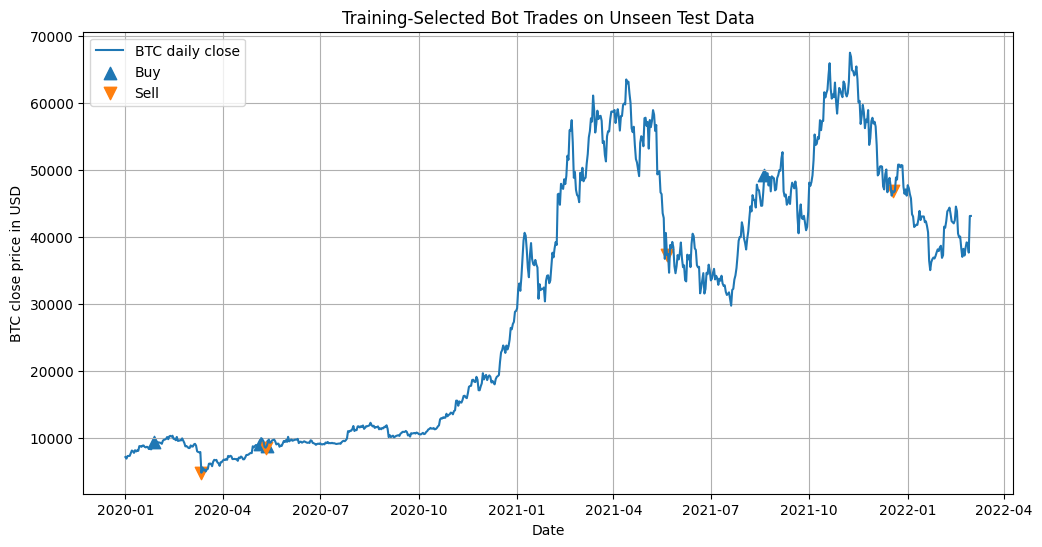

,index,action,price,cash,bitcoin
0,27,BUY,9400.00,0.000000,0.103191
1,71,SELL,4841.67,484.630564,0.000000
2,126,BUY,9154.32,0.000000,0.051352
3,131,SELL,8571.98,426.981765,0.000000
4,132,BUY,8825.46,0.000000,0.046929
5,506,SELL,37335.16,1699.548109,0.000000
6,597,BUY,49356.00,0.000000,0.033401
7,717,SELL,46881.87,1518.944487,0.000000


In [ ]:
training_selected_test_result = backtest_test_with_warmup(
    training_selected_params,
    warmup_prices,
    test_prices
)

training_selected_trades_df = pd.DataFrame(training_selected_test_result["trades"])

plt.figure(figsize=(12, 6))
plt.plot(test_data["date"], test_data["close"], label="BTC daily close")

if not training_selected_trades_df.empty:
    buy_trades = training_selected_trades_df[
        training_selected_trades_df["action"] == "BUY"
    ]
    sell_trades = training_selected_trades_df[
        training_selected_trades_df["action"].isin(["SELL", "FINAL_SELL"])
    ]

    plt.scatter(
        test_data.iloc[buy_trades["index"]]["date"],
        buy_trades["price"],
        marker="^",
        s=80,
        label="Buy"
    )

    plt.scatter(
        test_data.iloc[sell_trades["index"]]["date"],
        sell_trades["price"],
        marker="v",
        s=80,
        label="Sell"
    )

plt.xlabel("Date")
plt.ylabel("BTC close price in USD")
plt.title("Training-Selected Bot Trades on Unseen Test Data")
plt.legend()
plt.grid(True)
plt.savefig("training_selected_bot_test_trades.png", dpi=300, bbox_inches="tight")
plt.show()

training_selected_trades_df

### Training-Selected Bot Trade Interpretation

The training-selected GA bot made eight transactions during the unseen test period and finished with USD 1,518.94. The first two completed trades were unsuccessful, as the bot bought in early 2020 and sold after price drops, reducing the portfolio below the starting USD 1,000.

The third completed trade was much stronger. The bot bought again in 2020 and sold during the 2021 price rise, which helped the portfolio recover to about USD 1,699.55. However, the final completed trade bought near USD 49,356 and sold near USD 46,882, reducing the final value to USD 1,518.94.

The plot shows why the training-selected bot still underperformed buy-and-hold. The bot was not continuously exposed to Bitcoin during the full test-period bull market, and each buy or sell action paid the 3% transaction fee. This supports the earlier result that the optimised crossover strategy generated positive return, but did not match the buy-and-hold baseline on the unseen test period.

## Best Observed Test Run: Post-Hoc Diagnostic

For diagnostic interest, we also report the run that achieved the highest test fitness across all methods. This is not our final selected bot, because selecting on test fitness would use the test set for model selection. We include it only to show the range of test performance produced by the optimisers.

In the 15-seed experiment, the best observed test run was SA seed 10, with a test fitness of USD 4,394.14. This was a strong individual test result, but it still remained below the test buy-and-hold baseline of USD 5,660.26, so it does not change the main conclusion that the crossover-based bot did not beat buy-and-hold on the unseen test period.

In [ ]:
all_methods_results_df = pd.concat(
    [ga_results_df, pso_results_df, de_results_df, sa_results_df],
    ignore_index=True
)

best_test_index = all_methods_results_df["Test Fitness"].idxmax()
best_observed_test_run = all_methods_results_df.loc[best_test_index]

print("Best observed test run")
print(f"Algorithm: {best_observed_test_run['Algorithm']}")
print(f"Seed: {best_observed_test_run['Seed']}")
print(f"Training fitness: ${best_observed_test_run['Best Train Fitness']:,.2f}")
print(f"Test fitness: ${best_observed_test_run['Test Fitness']:,.2f}")
print(f"Number of test trades: {best_observed_test_run['Number of Trades']}")
print()
print("This run is reported only as a post-hoc diagnostic and is not used for final bot selection.")

Best observed test run
Algorithm: SA
Seed: 10
Training fitness: $52,021.14
Test fitness: $4,394.14
Number of test trades: 6

This run is reported only as a post-hoc diagnostic and is not used for final bot selection.


## Final Conclusion

This experiment compared three population-based optimisation algorithms, GA, PSO, and DE, for optimising the same 14-dimensional crossover trading-bot design. We also added SA as a single-state adaptive baseline. All methods used the same Bitcoin dataset, train/test split, parameter bounds, 15 fixed seeds, evaluation budget, fitness function, starting cash, transaction fee, and warmup-based test evaluation.

Among the four methods, PSO achieved the highest mean test fitness at USD 2,163.64, followed by DE, SA, and GA. However, the paired Wilcoxon tests did not show significant differences between any pair of methods at the 0.05 level. SA, despite being a single-state baseline, performed comparably to the population-based methods and produced the highest individual test result, with a test fitness of USD 4,394.14. This suggests that, for this problem, optimiser choice had less influence on test-period performance than the bot design, transaction fee, and train/test generalisation limitations.

The final bot was selected using training fitness only. This avoids using the unseen test period for model selection. The training-selected final bot was GA seed 7, which achieved a training fitness of USD 65,301.57 and a test fitness of USD 1,518.94. This large difference between training and testing performance shows that the optimised strategy fitted the pre-2020 training period much better than it generalised to the 2020 onwards test period.

The 2D SMA crossover baseline helped test the effect of bot complexity. The simpler 2D bot had a lower mean training fitness than the 14D weighted SMA/LMA/EMA bot, showing that the richer design gave the optimiser more flexibility. However, the improvement in test fitness was much smaller than the improvement in training fitness. This supports the main design trade-off: extra parameters can improve training fit, but they also increase the search space and can make overfitting more likely.

All methods beat the no-trade baseline of USD 1,000.00, so the optimisation algorithms did find trading parameters that generated positive return after transaction fees. However, none of the methods beat the test buy-and-hold baseline of USD 5,660.26. The main reasons are that the test period had a strong upward Bitcoin trend, the crossover bots sometimes exited the market during that trend, and each buy or sell action paid a 3% transaction fee.

Overall, the experiment shows that optimisation can improve the crossover bot compared with holding cash, but optimiser choice alone was not enough to beat buy-and-hold in this test period. The results suggest that the bot design, transaction fee assumption, and train/test generalisation problem were more important limitations than the choice between GA, PSO, DE, and SA. Future work could test different bot structures, lower transaction fees, multiple training windows, or fitness functions that penalise overfitting and excessive trading.